In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS_PUBLIC = PROJECT_ROOT / "artifacts" / "public"
DATA_PUBLIC = PROJECT_ROOT / "data" / "public"
MODELS_PUBLIC = PROJECT_ROOT / "models" / "public"

In [2]:
import json
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning, module="shap.explainers._tree")

registry_df = pd.read_csv(ARTIFACTS_PUBLIC / "metrics" / "final_baseline_vs_candidates.csv")
serving_default_metadata = json.loads((MODELS_PUBLIC / "baseline" / "metadata.json").read_text(encoding="utf-8"))
pure_champion_metadata = json.loads((MODELS_PUBLIC / "champion_pure" / "metadata.json").read_text(encoding="utf-8"))

# Day 05.3 · Error Analysis y SHAP antes de Day 05.4

Notebook de cierre y limpieza analítica de Day 05.3. Aquí no abrimos Brent, no reentrenamos y no implementamos todavía nuevas policies: dejamos una lectura auditable, compacta y defendible de cómo se comparan baseline y champion, qué slices explican sus errores y qué hallazgos quedan listos para pasar por gate en Day 05.4.


## Contexto heredado y propósito del bloque

Day 05, Day 05.1 y Day 05.2 ya están cerrados. El champion puro vigente es `V2_TRANSPORT_ONLY_LIGHTGBM_CLASS_WEIGHT_BALANCED_v1`, el serving default sigue congelado en `LR_smote_0.5` por decisión de despliegue y la mejor policy operativa vigente sigue siendo la basada en LR. Este notebook existe para cerrar Day 05.3 con una narrativa clara: entender dónde gana el champion, dónde todavía aporta valor local el baseline y qué tipos de hallazgo merecen implementación controlada en Day 05.4.


## Qué son Error Analysis y SHAP en este proyecto

`Error Analysis` es revisar sistemáticamente **dónde falla** el modelo y en qué contextos lo hace. `SHAP` es una técnica de explicabilidad que ayuda a ver qué señales están empujando esas decisiones. Aquí no se usan como decoración: se usan para separar qué errores huelen a fallback o flag local y cuáles apuntan a falta de señal en el stack actual.


### Por qué este bloque entra antes de Day 05.4


Este análisis se hace sobre el holdout oficial, no sobre train. La pregunta no es “cómo saco otra métrica”, sino “en qué casos puedo confiar más o menos en el champion y qué tipo de intervención tendría sentido probar después”.

En este proyecto el bloque es especialmente útil porque la policy aplicada sobre el nuevo champion dejó `overrides_harmed = 3`. Por eso aquí buscamos una lectura más fina: qué errores son locales y accionables, cuáles expresan complementariedad baseline/champion y cuáles apuntan a falta de señal más que a una regla simple.


### Qué papel juega SHAP aquí

`SHAP` entra en dos niveles distintos:

- `SHAP focalizado`: explicar un slice concreto donde el champion empeora y comprobar si las señales diferenciales son traducibles a thresholds, flags o fallback local.
- `SHAP global`: resumir qué familias de señal pesan más en el champion puro sobre el holdout completo. Su valor aquí es narrativo y de portfolio, no de policy directa.


## Reconstrucción del holdout y reconciliación oficial


### Dataframe `df_holdout_candidates`

- Este dataframe es el común para evaluar a los modelos. Sobre él se ejecutará la inferencia para hacer Error Analysis.

In [3]:
# Primer df: df_holdout_candidates

# Holdout maestro para Error Analysis:
# usamos V2_TRANSPORT_ONLY porque contiene las columnas del champion vigente
# y también las columnas base que luego necesita el baseline.

from src.ml.shared.day05_tabular import (
    get_day05_dataset_catalog,
    prepare_day05_model_frame,
    split_day05_by_cutoff,
)

CUTOFF_DATE = "2028-02-21"
DATASET_ALIAS_MASTER = "V2_TRANSPORT_ONLY"

dataset_catalog = get_day05_dataset_catalog(PROJECT_ROOT)
master_spec = dataset_catalog[DATASET_ALIAS_MASTER]

raw_master_df = pd.read_csv(master_spec["dataset_path"])

master_model_df = prepare_day05_model_frame(
    dataset_df=raw_master_df,
    feature_cols_num=master_spec["feature_cols_num"],
    feature_cols_cat=master_spec["feature_cols_cat"],
    target_col=master_spec["target_col"],
)

_, df_holdout_candidates = split_day05_by_cutoff(
    dataset_df=master_model_df,
    cutoff_date=CUTOFF_DATE,
)

df_holdout_candidates = df_holdout_candidates.sort_values(
    ["fecha_evento", "event_id", "proveedor_candidato"]
).reset_index(drop=True)

print("Dataset maestro:", DATASET_ALIAS_MASTER)
print("Ruta:", master_spec["dataset_path"])
print("Cutoff:", CUTOFF_DATE)
print("Rows holdout:", len(df_holdout_candidates))
print("Eventos holdout:", df_holdout_candidates["event_id"].nunique())
print("Target col:", master_spec["target_col"])

display(df_holdout_candidates.head())




Dataset maestro: V2_TRANSPORT_ONLY
Ruta: ./data/public/day041/dataset_modelo_v2_transport_only.csv
Cutoff: 2028-02-21
Rows holdout: 20852
Eventos holdout: 2633
Target col: target_elegido


,event_id,fecha_evento,albaran_id,linea_id,producto_canonico,terminal_compra,proveedor_elegido_real,proveedor_candidato,coste_min_dia_proveedor,rank_coste_dia_producto,...,v41_transport_ratio_vs_min_event,v41_transport_cost_min_day_provider_missing_flag,v41_transport_cost_mean_day_provider_missing_flag,v41_transport_cost_range_day_provider_missing_flag,v41_transport_observations_missing_flag,v41_transport_unique_terminal_count_missing_flag,v41_transport_multi_terminal_share_missing_flag,v41_transport_rank_event_missing_flag,v41_transport_gap_vs_min_event_missing_flag,v41_transport_ratio_vs_min_event_missing_flag
0,EVENT_2D8164FF34FE,2028-02-22,ALBARAN_2D8503F52B0C,LINE_ECBE43367EA4,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_007,1044.00,2.0,...,1.007722,0,0,0,0,0,0,0,0,0
1,EVENT_2D8164FF34FE,2028-02-22,ALBARAN_2D8503F52B0C,LINE_ECBE43367EA4,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,1104.92,3.0,...,1.066525,0,0,0,0,0,0,0,0,0
2,EVENT_2D8164FF34FE,2028-02-22,ALBARAN_2D8503F52B0C,LINE_ECBE43367EA4,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_019,1149.92,6.0,...,1.109961,0,0,0,0,0,0,0,0,0
3,EVENT_2D8164FF34FE,2028-02-22,ALBARAN_2D8503F52B0C,LINE_ECBE43367EA4,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_020,1129.47,4.0,...,1.090222,0,0,0,0,0,0,0,0,0
4,EVENT_2D8164FF34FE,2028-02-22,ALBARAN_2D8503F52B0C,LINE_ECBE43367EA4,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_050,1133.03,5.0,...,1.093658,0,0,0,0,0,0,0,0,0


In [4]:
# Validación mínima del holdout maestro

assert df_holdout_candidates["fecha_evento"].min() > pd.Timestamp(CUTOFF_DATE), "El holdout contiene filas de train."
assert df_holdout_candidates["event_id"].nunique() == 2633, "El número de eventos del holdout no coincide con el contrato oficial."
assert master_spec["target_col"] in df_holdout_candidates.columns, "Falta la columna target."
assert df_holdout_candidates["event_id"].notna().all(), "Hay event_id nulos en holdout."
assert df_holdout_candidates["proveedor_candidato"].notna().all(), "Hay proveedores candidatos nulos."

display(
    df_holdout_candidates[
        [
            "event_id",
            "fecha_evento",
            "proveedor_candidato",
            "producto_canonico",
            "terminal_compra",
            master_spec["target_col"],
        ]
    ].head(10)
)


,event_id,fecha_evento,proveedor_candidato,producto_canonico,terminal_compra,target_elegido
0,EVENT_2D8164FF34FE,2028-02-22,SUPPLIER_007,PRODUCT_002,TERMINAL_001,0
1,EVENT_2D8164FF34FE,2028-02-22,SUPPLIER_009,PRODUCT_002,TERMINAL_001,1
2,EVENT_2D8164FF34FE,2028-02-22,SUPPLIER_019,PRODUCT_002,TERMINAL_001,0
3,EVENT_2D8164FF34FE,2028-02-22,SUPPLIER_020,PRODUCT_002,TERMINAL_001,0
4,EVENT_2D8164FF34FE,2028-02-22,SUPPLIER_050,PRODUCT_002,TERMINAL_001,0
5,EVENT_2D8164FF34FE,2028-02-22,SUPPLIER_065,PRODUCT_002,TERMINAL_001,0
6,EVENT_2E389C4A5179,2028-02-22,SUPPLIER_009,PRODUCT_003,TERMINAL_001,1
7,EVENT_2E389C4A5179,2028-02-22,SUPPLIER_019,PRODUCT_003,TERMINAL_001,0
8,EVENT_2E389C4A5179,2028-02-22,SUPPLIER_020,PRODUCT_003,TERMINAL_001,0
9,EVENT_2E389C4A5179,2028-02-22,SUPPLIER_050,PRODUCT_003,TERMINAL_001,0


In [5]:
# Predicciones comparables sobre el mismo holdout:
# baseline (serving default) vs champion puro vigente

from src.ml.product.recommend_supplier import build_feature_matrix, infer


def build_transport_only_matrix_for_champion(
    df: pd.DataFrame,
    feature_cols_num: list[str],
    feature_cols_cat: list[str],
    expected_feature_columns: list[str],
) -> pd.DataFrame:
    """Rebuild the official V2_TRANSPORT_ONLY one-hot matrix used by the promoted LightGBM champion."""
    working = df.copy()

    for column in feature_cols_num:
        working[column] = pd.to_numeric(working[column], errors="coerce").fillna(0.0)

    for column in feature_cols_cat:
        working[column] = (
            working[column]
            .astype("string")
            .fillna("UNKNOWN")
            .str.strip()
            .replace("", "UNKNOWN")
        )

    matrix = pd.get_dummies(
        working[feature_cols_num + feature_cols_cat],
        drop_first=False,
    )
    matrix = matrix.reindex(columns=expected_feature_columns, fill_value=0.0)
    matrix = matrix.apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(float)
    return matrix


BASELINE_MODEL_PATH = PROJECT_ROOT / "models/public/baseline/model.pkl"
PURE_CHAMPION_MODEL_PATH = PROJECT_ROOT / "models/public/champion_pure/model.pkl"

baseline_model = joblib.load(BASELINE_MODEL_PATH)
pure_champion_model = joblib.load(PURE_CHAMPION_MODEL_PATH)

baseline_feature_columns = serving_default_metadata["feature_columns"]
pure_champion_feature_columns = pure_champion_metadata["feature_columns"]

# Matriz baseline: helper genérico V2 base.
X_holdout_baseline = build_feature_matrix(
    df=df_holdout_candidates,
    expected_feature_columns=baseline_feature_columns,
)

# Matriz champion: helper local que respeta el contrato real V2_TRANSPORT_ONLY.
X_holdout_pure_champion = build_transport_only_matrix_for_champion(
    df=df_holdout_candidates,
    feature_cols_num=master_spec["feature_cols_num"],
    feature_cols_cat=master_spec["feature_cols_cat"],
    expected_feature_columns=pure_champion_feature_columns,
)

# Columnas de auditoría que queremos conservar para slices posteriores
audit_cols = [
    "event_id",
    "fecha_evento",
    "proveedor_candidato",
    "producto_canonico",
    "terminal_compra",
    "candidatos_evento_count",
    "coste_min_dia_proveedor",
    "delta_vs_min_evento",
    "ratio_vs_min_evento",
    master_spec["target_col"],
]

df_preds_baseline = infer(
    df=df_holdout_candidates[audit_cols].copy(),
    matrix=X_holdout_baseline,
    model=baseline_model,
    event_col="event_id",
    top_k=2,
).rename(
    columns={
        "score_model": "score_baseline",
        "pred_label": "pred_label_baseline",
        "rank_event_score": "rank_baseline",
        "is_top1": "is_top1_baseline",
        "is_topk": "is_top2_baseline",
    }
)

df_preds_pure_champion = infer(
    df=df_holdout_candidates[audit_cols].copy(),
    matrix=X_holdout_pure_champion,
    model=pure_champion_model,
    event_col="event_id",
    top_k=2,
).rename(
    columns={
        "score_model": "score_pure_champion",
        "pred_label": "pred_label_pure_champion",
        "rank_event_score": "rank_pure_champion",
        "is_top1": "is_top1_pure_champion",
        "is_topk": "is_top2_pure_champion",
    }
)

print("Rows baseline preds:", len(df_preds_baseline))
print("Rows pure champion preds:", len(df_preds_pure_champion))
print("Eventos baseline:", df_preds_baseline["event_id"].nunique())
print("Eventos pure champion:", df_preds_pure_champion["event_id"].nunique())

display(df_preds_baseline.head())
display(df_preds_pure_champion.head())



Rows baseline preds: 20852
Rows pure champion preds: 20852
Eventos baseline: 2633
Eventos pure champion: 2633


,event_id,fecha_evento,proveedor_candidato,producto_canonico,terminal_compra,candidatos_evento_count,coste_min_dia_proveedor,delta_vs_min_evento,ratio_vs_min_evento,target_elegido,score_baseline,pred_label_baseline,rank_baseline,is_top1_baseline,is_top2_baseline
0,EVENT_001E84032733,2029-06-16,SUPPLIER_009,PRODUCT_003,TERMINAL_001,8,688.51,0.14,1.000203,0,0.916445,1,1,1,1
1,EVENT_001E84032733,2029-06-16,SUPPLIER_050,PRODUCT_003,TERMINAL_001,8,713.13,24.76,1.035969,0,0.429605,0,2,0,1
2,EVENT_001E84032733,2029-06-16,SUPPLIER_019,PRODUCT_003,TERMINAL_001,8,688.37,0.00,1.000000,0,0.225363,0,3,0,0
3,EVENT_001E84032733,2029-06-16,SUPPLIER_049,PRODUCT_003,TERMINAL_001,8,696.20,7.83,1.011375,1,0.058627,0,4,0,0
4,EVENT_001E84032733,2029-06-16,SUPPLIER_020,PRODUCT_003,TERMINAL_001,8,716.93,28.56,1.041489,0,0.033597,0,5,0,0


,event_id,fecha_evento,proveedor_candidato,producto_canonico,terminal_compra,candidatos_evento_count,coste_min_dia_proveedor,delta_vs_min_evento,ratio_vs_min_evento,target_elegido,score_pure_champion,pred_label_pure_champion,rank_pure_champion,is_top1_pure_champion,is_top2_pure_champion
0,EVENT_001E84032733,2029-06-16,SUPPLIER_009,PRODUCT_003,TERMINAL_001,8,688.51,0.14,1.000203,0,0.950052,1,1,1,1
1,EVENT_001E84032733,2029-06-16,SUPPLIER_019,PRODUCT_003,TERMINAL_001,8,688.37,0.00,1.000000,0,0.677147,1,2,0,1
2,EVENT_001E84032733,2029-06-16,SUPPLIER_050,PRODUCT_003,TERMINAL_001,8,713.13,24.76,1.035969,0,0.215943,0,3,0,0
3,EVENT_001E84032733,2029-06-16,SUPPLIER_025,PRODUCT_003,TERMINAL_001,8,699.51,11.14,1.016183,0,0.030918,0,4,0,0
4,EVENT_001E84032733,2029-06-16,SUPPLIER_020,PRODUCT_003,TERMINAL_001,8,716.93,28.56,1.041489,0,0.006437,0,5,0,0


In [6]:
# Validación mínima correcta: mismo universo, aunque cambie el ranking

baseline_keys = df_preds_baseline[["event_id", "proveedor_candidato"]].copy()
champion_keys = df_preds_pure_champion[["event_id", "proveedor_candidato"]].copy()

baseline_key_set = set(map(tuple, baseline_keys.to_numpy()))
champion_key_set = set(map(tuple, champion_keys.to_numpy()))

assert len(df_preds_baseline) == len(df_preds_pure_champion), "No coincide el número de filas."
assert df_preds_baseline["event_id"].nunique() == df_preds_pure_champion["event_id"].nunique(), "No coincide el número de eventos."
assert baseline_key_set == champion_key_set, "Los modelos no están prediciendo sobre el mismo universo de candidatos."

print("OK: baseline y champion comparten el mismo universo de holdout.")


OK: baseline y champion comparten el mismo universo de holdout.


In [7]:
# Alineación correcta baseline vs champion por clave de negocio para comparaciones
# Y búsqueda de patrones


df_compare_candidates = (
    df_preds_baseline[
        [
            "event_id",
            "proveedor_candidato",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "candidatos_evento_count",
            "coste_min_dia_proveedor",
            "delta_vs_min_evento",
            "ratio_vs_min_evento",
            master_spec["target_col"],
            "score_baseline",
            "pred_label_baseline",
            "rank_baseline",
            "is_top1_baseline",
            "is_top2_baseline",
        ]
    ]
    .merge(
        df_preds_pure_champion[
            [
                "event_id",
                "proveedor_candidato",
                "score_pure_champion",
                "pred_label_pure_champion",
                "rank_pure_champion",
                "is_top1_pure_champion",
                "is_top2_pure_champion",
            ]
        ],
        on=["event_id", "proveedor_candidato"],
        how="inner",
        validate="one_to_one",
    )
)

print("Rows compare:", len(df_compare_candidates))
print("Eventos compare:", df_compare_candidates["event_id"].nunique())

display(df_compare_candidates.head())


Rows compare: 20852
Eventos compare: 2633


,event_id,proveedor_candidato,fecha_evento,producto_canonico,terminal_compra,candidatos_evento_count,coste_min_dia_proveedor,delta_vs_min_evento,ratio_vs_min_evento,target_elegido,score_baseline,pred_label_baseline,rank_baseline,is_top1_baseline,is_top2_baseline,score_pure_champion,pred_label_pure_champion,rank_pure_champion,is_top1_pure_champion,is_top2_pure_champion
0,EVENT_001E84032733,SUPPLIER_009,2029-06-16,PRODUCT_003,TERMINAL_001,8,688.51,0.14,1.000203,0,0.916445,1,1,1,1,0.950052,1,1,1,1
1,EVENT_001E84032733,SUPPLIER_050,2029-06-16,PRODUCT_003,TERMINAL_001,8,713.13,24.76,1.035969,0,0.429605,0,2,0,1,0.215943,0,3,0,0
2,EVENT_001E84032733,SUPPLIER_019,2029-06-16,PRODUCT_003,TERMINAL_001,8,688.37,0.00,1.000000,0,0.225363,0,3,0,0,0.677147,1,2,0,1
3,EVENT_001E84032733,SUPPLIER_049,2029-06-16,PRODUCT_003,TERMINAL_001,8,696.20,7.83,1.011375,1,0.058627,0,4,0,0,0.002101,0,6,0,0
4,EVENT_001E84032733,SUPPLIER_020,2029-06-16,PRODUCT_003,TERMINAL_001,8,716.93,28.56,1.041489,0,0.033597,0,5,0,0,0.006437,0,5,0,0


In [8]:
# Dataframe a nivel evento:
# una fila por event_id para comparar baseline vs champion puro

target_col = master_spec["target_col"]

# 1) Validación: debe haber exactamente una fila positiva por evento
positive_counts = (
    df_compare_candidates.groupby("event_id")[target_col]
    .sum()
    .rename("positive_count")
)

assert (positive_counts == 1).all(), (
    "Cada event_id debería tener exactamente una fila positiva en holdout. "
    "Revisa el target o el grano del dataset."
)

# 2) Proveedor real y ranks de la fila positiva
positive_rows = df_compare_candidates.loc[
    df_compare_candidates[target_col] == 1,
    [
        "event_id",
        "proveedor_candidato",
        "rank_baseline",
        "rank_pure_champion",
        "score_baseline",
        "score_pure_champion",
    ],
].copy()

positive_rows = positive_rows.rename(
    columns={
        "proveedor_candidato": "proveedor_real",
        "rank_baseline": "rank_real_baseline",
        "rank_pure_champion": "rank_real_pure_champion",
        "score_baseline": "score_real_baseline",
        "score_pure_champion": "score_real_pure_champion",
    }
)

# 3) Top-1 recomendado por cada modelo
baseline_top1 = df_compare_candidates.loc[
    df_compare_candidates["rank_baseline"] == 1,
    ["event_id", "proveedor_candidato", "score_baseline"],
].copy().rename(
    columns={
        "proveedor_candidato": "top1_provider_baseline",
        "score_baseline": "top1_score_baseline",
    }
)

pure_champion_top1 = df_compare_candidates.loc[
    df_compare_candidates["rank_pure_champion"] == 1,
    ["event_id", "proveedor_candidato", "score_pure_champion"],
].copy().rename(
    columns={
        "proveedor_candidato": "top1_provider_pure_champion",
        "score_pure_champion": "top1_score_pure_champion",
    }
)

# 4) Atributos del evento para slices posteriores
event_features = (
    df_compare_candidates.groupby("event_id", as_index=False)
    .agg(
        fecha_evento=("fecha_evento", "first"),
        producto_canonico=("producto_canonico", "first"),
        terminal_compra=("terminal_compra", "first"),
        candidatos_evento_count=("candidatos_evento_count", "first"),
        min_coste_evento=("coste_min_dia_proveedor", "min"),
        max_coste_evento=("coste_min_dia_proveedor", "max"),
        mean_coste_evento=("coste_min_dia_proveedor", "mean"),
    )
)

event_features["spread_coste_holdout_evento"] = (
    event_features["max_coste_evento"] - event_features["min_coste_evento"]
)

# 5) Montaje final a nivel evento
df_event_compare = (
    event_features
    .merge(positive_rows, on="event_id", how="inner", validate="one_to_one")
    .merge(baseline_top1, on="event_id", how="inner", validate="one_to_one")
    .merge(pure_champion_top1, on="event_id", how="inner", validate="one_to_one")
)

# 6) Flags de acierto por evento
df_event_compare["top1_hit_baseline"] = (
    df_event_compare["top1_provider_baseline"] == df_event_compare["proveedor_real"]
).astype(int)

df_event_compare["top1_hit_pure_champion"] = (
    df_event_compare["top1_provider_pure_champion"] == df_event_compare["proveedor_real"]
).astype(int)

df_event_compare["top2_hit_baseline"] = (
    df_event_compare["rank_real_baseline"] <= 2
).astype(int)

df_event_compare["top2_hit_pure_champion"] = (
    df_event_compare["rank_real_pure_champion"] <= 2
).astype(int)

# 7) Cambios del champion frente al baseline
df_event_compare["top1_changed_vs_baseline"] = (
    df_event_compare["top1_provider_baseline"] != df_event_compare["top1_provider_pure_champion"]
).astype(int)

df_event_compare["delta_rank_real_champion_vs_baseline"] = (
    df_event_compare["rank_real_pure_champion"] - df_event_compare["rank_real_baseline"]
)

df_event_compare["top1_result_vs_baseline"] = np.select(
    [
        (df_event_compare["top1_hit_baseline"] == 0) & (df_event_compare["top1_hit_pure_champion"] == 1),
        (df_event_compare["top1_hit_baseline"] == 1) & (df_event_compare["top1_hit_pure_champion"] == 0),
        (df_event_compare["top1_hit_baseline"] == 1) & (df_event_compare["top1_hit_pure_champion"] == 1),
        (df_event_compare["top1_hit_baseline"] == 0) & (df_event_compare["top1_hit_pure_champion"] == 0),
    ],
    [
        "champion_improves",
        "champion_worsens",
        "both_hit",
        "both_fail",
    ],
    default="unknown",
)

df_event_compare["top2_result_vs_baseline"] = np.select(
    [
        (df_event_compare["top2_hit_baseline"] == 0) & (df_event_compare["top2_hit_pure_champion"] == 1),
        (df_event_compare["top2_hit_baseline"] == 1) & (df_event_compare["top2_hit_pure_champion"] == 0),
        (df_event_compare["top2_hit_baseline"] == 1) & (df_event_compare["top2_hit_pure_champion"] == 1),
        (df_event_compare["top2_hit_baseline"] == 0) & (df_event_compare["top2_hit_pure_champion"] == 0),
    ],
    [
        "champion_improves",
        "champion_worsens",
        "both_hit",
        "both_fail",
    ],
    default="unknown",
)

print("Rows event compare:", len(df_event_compare))
print("Eventos únicos:", df_event_compare["event_id"].nunique())

display(df_event_compare.head())


Rows event compare: 2633
Eventos únicos: 2633


,event_id,fecha_evento,producto_canonico,terminal_compra,candidatos_evento_count,min_coste_evento,max_coste_evento,mean_coste_evento,spread_coste_holdout_evento,proveedor_real,...,top1_provider_pure_champion,top1_score_pure_champion,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,top1_changed_vs_baseline,delta_rank_real_champion_vs_baseline,top1_result_vs_baseline,top2_result_vs_baseline
0,EVENT_001E84032733,2029-06-16,PRODUCT_003,TERMINAL_001,8,688.37,717.59,702.936250,29.22,SUPPLIER_049,...,SUPPLIER_009,0.950052,0,0,0,0,0,2,both_fail,both_fail
1,EVENT_003CCE93DDDB,2029-07-18,PRODUCT_003,TERMINAL_001,9,720.00,750.46,734.951111,30.46,SUPPLIER_009,...,SUPPLIER_009,0.827936,1,1,1,1,0,0,both_hit,both_hit
2,EVENT_0042710C9C0D,2029-04-24,PRODUCT_003,TERMINAL_001,10,640.10,681.00,653.255000,40.90,SUPPLIER_009,...,SUPPLIER_009,0.947457,1,1,1,1,0,0,both_hit,both_hit
3,EVENT_006E91B098BC,2028-03-22,PRODUCT_002,TERMINAL_001,11,923.00,1130.70,1057.723636,207.70,SUPPLIER_009,...,SUPPLIER_009,0.922760,0,1,1,1,1,-1,champion_improves,both_hit
4,EVENT_0082D7C58268,2028-04-26,PRODUCT_003,TERMINAL_001,9,801.11,834.00,818.717778,32.89,SUPPLIER_009,...,SUPPLIER_009,0.955804,1,1,1,1,0,0,both_hit,both_hit


In [9]:
# Validación del dataframe a nivel evento + reconciliación con artefactos oficiales

from sklearn.metrics import balanced_accuracy_score

assert len(df_event_compare) == df_holdout_candidates["event_id"].nunique(), "df_event_compare no tiene una fila por evento."
assert df_event_compare["event_id"].is_unique, "Hay event_id duplicados en df_event_compare."

baseline_top1_nb = float(df_event_compare["top1_hit_baseline"].mean())
baseline_top2_nb = float(df_event_compare["top2_hit_baseline"].mean())
champion_top1_nb = float(df_event_compare["top1_hit_pure_champion"].mean())
champion_top2_nb = float(df_event_compare["top2_hit_pure_champion"].mean())

baseline_bal_acc_nb = float(
    balanced_accuracy_score(df_preds_baseline[target_col], df_preds_baseline["pred_label_baseline"])
)
champion_bal_acc_nb = float(
    balanced_accuracy_score(df_preds_pure_champion[target_col], df_preds_pure_champion["pred_label_pure_champion"])
)

baseline_registry_row = registry_df.loc[registry_df["model_variant"] == "LR_smote_0.5"].iloc[0]
champion_registry_row = registry_df.loc[
    registry_df["model_variant"] == "V2_TRANSPORT_ONLY_LIGHTGBM_CLASS_WEIGHT_BALANCED_v1"
].iloc[0]

metrics_reconciliation = pd.DataFrame(
    [
        {
            "model": "baseline",
            "metric": "top1_hit",
            "notebook": baseline_top1_nb,
            "metadata": float(serving_default_metadata["metrics"]["top1_hit"]),
            "registry": float(baseline_registry_row["top1_hit"]),
        },
        {
            "model": "baseline",
            "metric": "top2_hit",
            "notebook": baseline_top2_nb,
            "metadata": float(serving_default_metadata["metrics"]["top2_hit"]),
            "registry": float(baseline_registry_row["top2_hit"]),
        },
        {
            "model": "baseline",
            "metric": "balanced_accuracy",
            "notebook": baseline_bal_acc_nb,
            "metadata": float(serving_default_metadata["metrics"]["balanced_accuracy"] if "balanced_accuracy" in serving_default_metadata["metrics"] else serving_default_metadata["metrics"]["test_bal_acc"]),
            "registry": float(baseline_registry_row["balanced_accuracy"]),
        },
        {
            "model": "pure_champion",
            "metric": "top1_hit",
            "notebook": champion_top1_nb,
            "metadata": float(pure_champion_metadata["metrics"]["top1_hit"]),
            "registry": float(champion_registry_row["top1_hit"]),
        },
        {
            "model": "pure_champion",
            "metric": "top2_hit",
            "notebook": champion_top2_nb,
            "metadata": float(pure_champion_metadata["metrics"]["top2_hit"]),
            "registry": float(champion_registry_row["top2_hit"]),
        },
        {
            "model": "pure_champion",
            "metric": "balanced_accuracy",
            "notebook": champion_bal_acc_nb,
            "metadata": float(pure_champion_metadata["metrics"]["balanced_accuracy"]),
            "registry": float(champion_registry_row["balanced_accuracy"]),
        },
    ]
)

metrics_reconciliation["delta_vs_metadata"] = metrics_reconciliation["notebook"] - metrics_reconciliation["metadata"]
metrics_reconciliation["delta_vs_registry"] = metrics_reconciliation["notebook"] - metrics_reconciliation["registry"]

display(metrics_reconciliation)

for _, row in metrics_reconciliation.iterrows():
    assert np.isclose(row["notebook"], row["metadata"], atol=1e-6), (
        f"Notebook no reproduce metadata oficial para {row['model']}::{row['metric']}"
    )
    assert np.isclose(row["notebook"], row["registry"], atol=1e-6), (
        f"Notebook no reproduce registry oficial para {row['model']}::{row['metric']}"
    )

print("OK: baseline y champion puro reproducen las métricas oficiales del repo.")

display(
    df_event_compare[
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
            "rank_real_baseline",
            "rank_real_pure_champion",
            "top1_hit_baseline",
            "top1_hit_pure_champion",
            "top2_hit_baseline",
            "top2_hit_pure_champion",
            "top1_result_vs_baseline",
            "top2_result_vs_baseline",
        ]
    ].head(10)
)



,model,metric,notebook,metadata,registry,delta_vs_metadata,delta_vs_registry
0,baseline,top1_hit,0.764527,0.764527,0.764527,0.0,1.553361e-07
1,baseline,top2_hit,0.858336,0.858336,0.858336,0.0,4.982909e-07
2,baseline,balanced_accuracy,0.865084,0.865084,0.865084,0.0,3.671483e-07
3,pure_champion,top1_hit,0.772503,0.772503,0.772503,0.0,-1.515382e-07
4,pure_champion,top2_hit,0.882643,0.882643,0.882643,0.0,3.725788e-07
5,pure_champion,balanced_accuracy,0.881431,0.881431,0.881431,0.0,3.704926e-07


OK: baseline y champion puro reproducen las métricas oficiales del repo.


,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,rank_real_baseline,rank_real_pure_champion,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,top1_result_vs_baseline,top2_result_vs_baseline
0,EVENT_001E84032733,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_049,SUPPLIER_009,SUPPLIER_009,4,6,0,0,0,0,both_fail,both_fail
1,EVENT_003CCE93DDDB,2029-07-18,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,1,1,both_hit,both_hit
2,EVENT_0042710C9C0D,2029-04-24,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,1,1,both_hit,both_hit
3,EVENT_006E91B098BC,2028-03-22,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_007,SUPPLIER_009,2,1,0,1,1,1,champion_improves,both_hit
4,EVENT_0082D7C58268,2028-04-26,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,1,1,both_hit,both_hit
5,EVENT_008CC9D475E4,2029-05-20,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,1,1,both_hit,both_hit
6,EVENT_0092F85E4DEF,2029-04-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,1,1,both_hit,both_hit
7,EVENT_0093B9968026,2029-06-13,PRODUCT_003,TERMINAL_001,SUPPLIER_049,SUPPLIER_050,SUPPLIER_009,4,3,0,0,0,0,both_fail,both_fail
8,EVENT_00A94647348A,2029-06-26,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,1,1,both_hit,both_hit
9,EVENT_00ACCF4EC437,2028-04-10,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,1,1,both_hit,both_hit


## Lectura global baseline vs champion

Primero fijamos la foto macro. Antes de abrir slices concretas, necesitamos ver qué parte de la mejora del champion es limpia, qué parte viene con coste local y dónde aparecen ya bolsas de error compartido frente al administrativo.


### Resumen macro y primeras bolsas de error


In [10]:
# Resumen general del cambio baseline vs champion 

## Aquí habría que comprobar también otros hits en donde champion empeora

summary_top1 = (
    df_event_compare["top1_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top1_result_vs_baseline")
    .reset_index(name="event_count")
)

summary_top1["share"] = summary_top1["event_count"] / len(df_event_compare)

summary_top2 = (
    df_event_compare["top2_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top2_result_vs_baseline")
    .reset_index(name="event_count")
)

summary_top2["share"] = summary_top2["event_count"] / len(df_event_compare)

display(Markdown("### Resumen general · Top-1"))
display(summary_top1)

display(Markdown("### Resumen general · Top-2"))
display(summary_top2)


### Resumen general · Top-1

,top1_result_vs_baseline,event_count,share
0,both_hit,1916,0.727687
1,both_fail,502,0.190657
2,champion_improves,118,0.044816
3,champion_worsens,97,0.036840


### Resumen general · Top-2

,top2_result_vs_baseline,event_count,share
0,both_hit,2184,0.829472
1,both_fail,233,0.088492
2,champion_improves,140,0.053171
3,champion_worsens,76,0.028864


#### EXPLICACIÓN · Lectura de la slice · Resumen general baseline vs champion

- En esta slice, a nivel de evento, miramos cómo cambia el resultado cuando pasamos del baseline `LR_smote_0.5` al champion puro `V2_TRANSPORT_ONLY_LIGHTGBM_CLASS_WEIGHT_BALANCED_v1` usando ya la reproducción correcta del champion.

- Qué vemos en Top-1:
  - Ambos modelos aciertan en `1916` eventos (`72.8%`).
  - Ambos fallan en `502` eventos (`19.1%`).
  - El champion mejora al baseline en `118` eventos (`4.5%`).
  - El champion empeora en `97` eventos (`3.7%`).

- Qué vemos en Top-2:
  - Ambos aciertan en `2184` eventos (`82.9%`).
  - Ambos fallan en `233` eventos (`8.8%`).
  - El champion mejora al baseline en `140` eventos (`5.3%`).
  - El champion empeora en `76` eventos (`2.9%`).

- Qué significa:
  - El champion sigue siendo mejor en las métricas oficiales, pero la mejora no viene de una señal “limpia” sin coste, sino de un balance neto positivo con una bolsa relevante de eventos donde también empeora.
  - En Top-1 la ganancia neta existe, pero ya no podemos hablar de un deterioro casi nulo.
  - En Top-2 la mejora sigue siendo clara, aunque aparecen slices donde el baseline todavía ordena mejor al proveedor real.

- Qué nos interesa investigar ahora:
  - Los `502` eventos donde ambos fallan en Top-1, porque ahí puede haber límites estructurales del problema.
  - Los `97` eventos `champion_worsens` en Top-1, porque ya no son anecdóticos y merecen auditoría real.
  - Los `76` casos `champion_worsens` en Top-2, porque pueden revelar slices donde el baseline conserva una ventaja local de ranking.

- Qué no podemos afirmar todavía:
  - Aún no sabemos por qué el champion mejora o empeora en esos slices.
  - Tampoco podemos sacar todavía una regla determinista.
  - Esta slide sigue siendo una foto macro para decidir dónde profundizar.

- Hipótesis siguientes:
  - Regla determinista candidata: no todavía.
  - SHAP focalizado: sí, si encontramos slices concentrados.
  - Hipótesis de ensemble: posible, porque ya hay señales de complementariedad local entre baseline y champion.


##### MICROAUDITORÍA · Lectura de profundización · casos donde el champion empeora

- Qué estamos mirando:
  - Aquí bajamos de la foto general a los eventos concretos donde el champion puro empeora respecto al baseline.

- Por qué lo hacemos ahora:
  - El champion mejora de forma clara en el agregado, pero los casos donde empeora son especialmente valiosos porque pueden revelar límites reales del modelo o slices donde el baseline sigue ordenando mejor la opción correcta.

- Qué buscamos:
  - Si el empeoramiento está concentrado en un producto, una terminal, una complejidad de evento o una dispersión de coste concreta.
  - Si el champion no solo falla, sino que además empuja claramente hacia abajo al proveedor real.

- Qué no decidimos todavía:
  - Aún no estamos proponiendo una regla determinista ni un ensemble.
  - Primero queremos comprobar si estos empeoramientos son casos aislados o un patrón repetible.


In [11]:
# Casos sensibles detectados en la slide general:
# - 1 caso donde el champion empeora Top-1
# - 31 casos donde el champion empeora Top-2

df_top1_worsens = (
    df_event_compare.loc[df_event_compare["top1_result_vs_baseline"] == "champion_worsens"]
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

df_top2_worsens = (
    df_event_compare.loc[df_event_compare["top2_result_vs_baseline"] == "champion_worsens"]
    .sort_values(["delta_rank_real_champion_vs_baseline", "fecha_evento", "event_id"], ascending=[False, True, True])
    .reset_index(drop=True)
)

print("Top-1 champion_worsens:", len(df_top1_worsens))
print("Top-2 champion_worsens:", len(df_top2_worsens))

display(Markdown("### Casos donde el champion empeora en Top-1"))
display(
    df_top1_worsens[
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
            "rank_real_baseline",
            "rank_real_pure_champion",
            "top1_hit_baseline",
            "top1_hit_pure_champion",
            "top2_hit_baseline",
            "top2_hit_pure_champion",
            "delta_rank_real_champion_vs_baseline",
            "candidatos_evento_count",
            "spread_coste_holdout_evento",
        ]
    ]
)

display(Markdown("### Primeros casos donde el champion empeora en Top-2"))
display(
    df_top2_worsens[
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
            "rank_real_baseline",
            "rank_real_pure_champion",
            "top1_hit_baseline",
            "top1_hit_pure_champion",
            "top2_hit_baseline",
            "top2_hit_pure_champion",
            "delta_rank_real_champion_vs_baseline",
            "candidatos_evento_count",
            "spread_coste_holdout_evento",
        ]
    ].head(20)
)


Top-1 champion_worsens: 97
Top-2 champion_worsens: 76


### Casos donde el champion empeora en Top-1

,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,rank_real_baseline,rank_real_pure_champion,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,delta_rank_real_champion_vs_baseline,candidatos_evento_count,spread_coste_holdout_evento
0,EVENT_1E3422502DA9,2028-03-06,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,1,2,1,0,1,1,1,7,37.75
1,EVENT_271907BC7CD1,2028-03-06,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,1,2,1,0,1,1,1,7,37.75
2,EVENT_39A4DE7561CF,2028-03-06,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,1,2,1,0,1,1,1,7,37.75
3,EVENT_6431061D9668,2028-03-06,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,1,2,1,0,1,1,1,7,37.75
4,EVENT_83CA8C9ADF86,2028-03-06,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,1,2,1,0,1,1,1,7,37.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,EVENT_5BDF92B55036,2029-07-11,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_019,1,2,1,0,1,1,1,6,33.02
93,EVENT_5DA20274FD9E,2029-07-11,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_019,1,2,1,0,1,1,1,6,33.02
94,EVENT_8AE8374E889C,2029-07-11,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_019,1,2,1,0,1,1,1,6,33.02
95,EVENT_98C6BD41B308,2029-07-11,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_019,1,2,1,0,1,1,1,6,33.02


### Primeros casos donde el champion empeora en Top-2

,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,rank_real_baseline,rank_real_pure_champion,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,delta_rank_real_champion_vs_baseline,candidatos_evento_count,spread_coste_holdout_evento
0,EVENT_F75ED4BAA153,2029-06-18,PRODUCT_002,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,7,0,0,1,0,5,10,338.681
1,EVENT_90AF48F0275A,2029-06-18,PRODUCT_002,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,5,0,0,1,0,3,10,338.681
2,EVENT_F0C5C4BBFA66,2029-06-18,PRODUCT_002,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,5,0,0,1,0,3,10,338.681
3,EVENT_C3C55A645C08,2028-03-06,PRODUCT_003,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_020,1,3,1,0,1,0,2,7,37.750
4,EVENT_E8F86BFD8EB4,2028-03-06,PRODUCT_003,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_020,1,3,1,0,1,0,2,7,37.750
5,EVENT_1F54A3E717E3,2028-04-02,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_008,1,3,1,0,1,0,2,7,113.600
6,EVENT_31958BC74892,2028-04-02,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_008,1,3,1,0,1,0,2,7,113.600
7,EVENT_346071841FCB,2028-04-02,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_008,1,3,1,0,1,0,2,7,113.600
8,EVENT_3A1535984CB0,2028-04-02,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_008,1,3,1,0,1,0,2,7,113.600
9,EVENT_642B72C55578,2028-04-02,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_008,1,3,1,0,1,0,2,7,113.600


In [12]:
# Lectura absoluta contra el administrativo / proveedor real
# Aquí no preguntamos "quién gana al otro", sino "quién se equivoca contra la realidad del negocio".

df_event_compare["error_top1_baseline"] = 1 - df_event_compare["top1_hit_baseline"]
df_event_compare["error_top1_pure_champion"] = 1 - df_event_compare["top1_hit_pure_champion"]

df_event_compare["error_top2_baseline"] = 1 - df_event_compare["top2_hit_baseline"]
df_event_compare["error_top2_pure_champion"] = 1 - df_event_compare["top2_hit_pure_champion"]

# Categoría absoluta Top-1 vs administrativo
df_event_compare["top1_abs_result_vs_admin"] = np.select(
    [
        (df_event_compare["top1_hit_baseline"] == 0) & (df_event_compare["top1_hit_pure_champion"] == 1),
        (df_event_compare["top1_hit_baseline"] == 1) & (df_event_compare["top1_hit_pure_champion"] == 0),
        (df_event_compare["top1_hit_baseline"] == 1) & (df_event_compare["top1_hit_pure_champion"] == 1),
        (df_event_compare["top1_hit_baseline"] == 0) & (df_event_compare["top1_hit_pure_champion"] == 0),
    ],
    [
        "only_baseline_fails",
        "only_champion_fails",
        "both_hit",
        "both_fail",
    ],
    default="unknown",
)

# Categoría absoluta Top-2 vs administrativo
df_event_compare["top2_abs_result_vs_admin"] = np.select(
    [
        (df_event_compare["top2_hit_baseline"] == 0) & (df_event_compare["top2_hit_pure_champion"] == 1),
        (df_event_compare["top2_hit_baseline"] == 1) & (df_event_compare["top2_hit_pure_champion"] == 0),
        (df_event_compare["top2_hit_baseline"] == 1) & (df_event_compare["top2_hit_pure_champion"] == 1),
        (df_event_compare["top2_hit_baseline"] == 0) & (df_event_compare["top2_hit_pure_champion"] == 0),
    ],
    [
        "only_baseline_fails",
        "only_champion_fails",
        "both_hit",
        "both_fail",
    ],
    default="unknown",
)

# Métricas de diferencia de error
df_event_compare["delta_error_top1_champion_vs_baseline"] = (
    df_event_compare["error_top1_pure_champion"] - df_event_compare["error_top1_baseline"]
)
df_event_compare["delta_error_top2_champion_vs_baseline"] = (
    df_event_compare["error_top2_pure_champion"] - df_event_compare["error_top2_baseline"]
)

# Resumen rápido
abs_summary_top1 = (
    df_event_compare["top1_abs_result_vs_admin"]
    .value_counts(dropna=False)
    .rename_axis("top1_abs_result_vs_admin")
    .reset_index(name="event_count")
)
abs_summary_top1["share"] = abs_summary_top1["event_count"] / len(df_event_compare)

abs_summary_top2 = (
    df_event_compare["top2_abs_result_vs_admin"]
    .value_counts(dropna=False)
    .rename_axis("top2_abs_result_vs_admin")
    .reset_index(name="event_count")
)
abs_summary_top2["share"] = abs_summary_top2["event_count"] / len(df_event_compare)

display(Markdown("### Resumen absoluto vs administrativo · Top-1"))
display(abs_summary_top1)

display(Markdown("### Resumen absoluto vs administrativo · Top-2"))
display(abs_summary_top2)

display(
    df_event_compare[
        [
            "event_id",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
            "top1_hit_baseline",
            "top1_hit_pure_champion",
            "top2_hit_baseline",
            "top2_hit_pure_champion",
            "top1_abs_result_vs_admin",
            "top2_abs_result_vs_admin",
            "delta_error_top1_champion_vs_baseline",
            "delta_error_top2_champion_vs_baseline",
        ]
    ].head(10)
)


### Resumen absoluto vs administrativo · Top-1

,top1_abs_result_vs_admin,event_count,share
0,both_hit,1916,0.727687
1,both_fail,502,0.190657
2,only_baseline_fails,118,0.044816
3,only_champion_fails,97,0.036840


### Resumen absoluto vs administrativo · Top-2

,top2_abs_result_vs_admin,event_count,share
0,both_hit,2184,0.829472
1,both_fail,233,0.088492
2,only_baseline_fails,140,0.053171
3,only_champion_fails,76,0.028864


,event_id,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,top1_abs_result_vs_admin,top2_abs_result_vs_admin,delta_error_top1_champion_vs_baseline,delta_error_top2_champion_vs_baseline
0,EVENT_001E84032733,SUPPLIER_049,SUPPLIER_009,SUPPLIER_009,0,0,0,0,both_fail,both_fail,0,0
1,EVENT_003CCE93DDDB,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,both_hit,both_hit,0,0
2,EVENT_0042710C9C0D,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,both_hit,both_hit,0,0
3,EVENT_006E91B098BC,SUPPLIER_009,SUPPLIER_007,SUPPLIER_009,0,1,1,1,only_baseline_fails,both_hit,-1,0
4,EVENT_0082D7C58268,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,both_hit,both_hit,0,0
5,EVENT_008CC9D475E4,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,both_hit,both_hit,0,0
6,EVENT_0092F85E4DEF,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,both_hit,both_hit,0,0
7,EVENT_0093B9968026,SUPPLIER_049,SUPPLIER_050,SUPPLIER_009,0,0,0,0,both_fail,both_fail,0,0
8,EVENT_00A94647348A,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,both_hit,both_hit,0,0
9,EVENT_00ACCF4EC437,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1,1,1,both_hit,both_hit,0,0


In [13]:
# Lectura de calidad de ranking del proveedor real, incluso cuando ambos fallan

df_event_compare["ranking_real_result_vs_baseline"] = np.select(
    [
        df_event_compare["rank_real_pure_champion"] < df_event_compare["rank_real_baseline"],
        df_event_compare["rank_real_pure_champion"] > df_event_compare["rank_real_baseline"],
        df_event_compare["rank_real_pure_champion"] == df_event_compare["rank_real_baseline"],
    ],
    [
        "champion_ranks_real_better",
        "baseline_ranks_real_better",
        "same_rank",
    ],
    default="unknown",
)

df_event_compare["both_fail_top1"] = (
    (df_event_compare["top1_hit_baseline"] == 0)
    & (df_event_compare["top1_hit_pure_champion"] == 0)
).astype(int)

df_event_compare["both_fail_top2"] = (
    (df_event_compare["top2_hit_baseline"] == 0)
    & (df_event_compare["top2_hit_pure_champion"] == 0)
).astype(int)

ranking_summary = (
    df_event_compare["ranking_real_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("ranking_real_result_vs_baseline")
    .reset_index(name="event_count")
)

display(ranking_summary)

display(
    df_event_compare[
        [
            "event_id",
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "rank_real_baseline",
            "rank_real_pure_champion",
            "delta_rank_real_champion_vs_baseline",
            "top1_hit_baseline",
            "top1_hit_pure_champion",
            "top2_hit_baseline",
            "top2_hit_pure_champion",
            "ranking_real_result_vs_baseline",
        ]
    ].head(15)
)


,ranking_real_result_vs_baseline,event_count
0,same_rank,2104
1,champion_ranks_real_better,302
2,baseline_ranks_real_better,227


,event_id,producto_canonico,terminal_compra,proveedor_real,rank_real_baseline,rank_real_pure_champion,delta_rank_real_champion_vs_baseline,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,ranking_real_result_vs_baseline
0,EVENT_001E84032733,PRODUCT_003,TERMINAL_001,SUPPLIER_049,4,6,2,0,0,0,0,baseline_ranks_real_better
1,EVENT_003CCE93DDDB,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,1,0,1,1,1,1,same_rank
2,EVENT_0042710C9C0D,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,1,0,1,1,1,1,same_rank
3,EVENT_006E91B098BC,PRODUCT_002,TERMINAL_001,SUPPLIER_009,2,1,-1,0,1,1,1,champion_ranks_real_better
4,EVENT_0082D7C58268,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,1,0,1,1,1,1,same_rank
5,EVENT_008CC9D475E4,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,1,0,1,1,1,1,same_rank
6,EVENT_0092F85E4DEF,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,1,0,1,1,1,1,same_rank
7,EVENT_0093B9968026,PRODUCT_003,TERMINAL_001,SUPPLIER_049,4,3,-1,0,0,0,0,champion_ranks_real_better
8,EVENT_00A94647348A,PRODUCT_002,TERMINAL_001,SUPPLIER_009,1,1,0,1,1,1,1,same_rank
9,EVENT_00ACCF4EC437,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,1,0,1,1,1,1,same_rank


In [14]:
# Slice por producto: dónde mejora o empeora más el champion

product_slice = (
    df_event_compare.groupby("producto_canonico", as_index=False)
    .agg(
        events=("event_id", "count"),
        top1_hit_baseline=("top1_hit_baseline", "mean"),
        top1_hit_pure_champion=("top1_hit_pure_champion", "mean"),
        top2_hit_baseline=("top2_hit_baseline", "mean"),
        top2_hit_pure_champion=("top2_hit_pure_champion", "mean"),
    )
)

product_slice["delta_top1"] = (
    product_slice["top1_hit_pure_champion"] - product_slice["top1_hit_baseline"]
)
product_slice["delta_top2"] = (
    product_slice["top2_hit_pure_champion"] - product_slice["top2_hit_baseline"]
)

product_slice = product_slice.sort_values(
    ["delta_top1", "delta_top2", "events"],
    ascending=[False, False, False],
)

display(product_slice)


,producto_canonico,events,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,delta_top1,delta_top2
0,PRODUCT_001,43,0.534884,0.627907,0.744186,0.813953,0.093023,0.069767
1,PRODUCT_002,783,0.634738,0.720307,0.800766,0.821201,0.085568,0.020434
5,PRODUCT_006,4,0.500000,0.500000,0.500000,1.000000,0.000000,0.500000
3,PRODUCT_004,1,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
2,PRODUCT_003,1702,0.819036,0.800823,0.881316,0.905405,-0.018214,0.024089
4,PRODUCT_005,100,0.960000,0.770000,0.980000,1.000000,-0.190000,0.020000


### Priorización inicial por producto en el holdout

Esta lectura sirve para decidir dónde merece la pena profundizar primero. No abre todavía una policy: solo ordena el mapa de slices para separar las que ya huelen a intervención local de las que solo aportan contexto.


### Champion_worsens en Top-2: por qué abrimos este slice

La bolsa `champion_worsens` en `Top-2` es pequeña en porcentaje, pero suficientemente relevante como para merecer auditoría específica. Aquí buscamos si el deterioro es disperso o si existe un slice dominante defendible para explicabilidad local y posterior simulación operativa.


In [15]:
# Slice rápido de los casos champion_worsens en Top-2

top2_worsens_product_slice = (
    df_top2_worsens.groupby("producto_canonico", as_index=False)
    .agg(
        events=("event_id", "count"),
        mean_delta_rank_real=("delta_rank_real_champion_vs_baseline", "mean"),
        mean_candidates=("candidatos_evento_count", "mean"),
        mean_spread=("spread_coste_holdout_evento", "mean"),
    )
    .sort_values(["events", "mean_delta_rank_real"], ascending=[False, False])
)

display(top2_worsens_product_slice)


,producto_canonico,events,mean_delta_rank_real,mean_candidates,mean_spread
2,PRODUCT_003,46,1.043478,6.478261,44.065217
1,PRODUCT_002,28,1.892857,9.000000,195.215857
0,PRODUCT_001,2,2.000000,7.000000,77.100000


### Priorización dentro de `champion_worsens` en Top-2

A nivel de producto, `PRODUCT_003` concentra el mayor volumen y `PRODUCT_002` concentra deterioros más severos. Eso justifica usar `PRODUCT_003` como primer slice dominante para explicabilidad local y dejar `PRODUCT_002` como régimen secundario a revisar solo si el hallazgo principal resulta accionable.


In [16]:
# Cuantificar concentración del patrón champion_worsens en Top-2
# por producto + terminal + proveedor real + top1 predicho

top2_worsens_pattern_slice = (
    df_top2_worsens.groupby(
        [
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
        ],
        as_index=False,
    )
    .agg(
        events=("event_id", "count"),
        unique_dates=("fecha_evento", "nunique"),
        mean_rank_real_baseline=("rank_real_baseline", "mean"),
        mean_rank_real_pure_champion=("rank_real_pure_champion", "mean"),
        mean_delta_rank_real=("delta_rank_real_champion_vs_baseline", "mean"),
        mean_candidates=("candidatos_evento_count", "mean"),
        mean_spread=("spread_coste_holdout_evento", "mean"),
    )
    .sort_values(
        ["events", "mean_delta_rank_real", "unique_dates"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

top2_worsens_pattern_slice["share_within_top2_worsens"] = (
    top2_worsens_pattern_slice["events"] / len(df_top2_worsens)
)

display(Markdown("### Concentración del patrón `champion_worsens` en Top-2"))
display(top2_worsens_pattern_slice)

# Slice dominante para el siguiente paso (SHAP focalizado)
focus_pattern = top2_worsens_pattern_slice.iloc[0].to_dict()

display(Markdown("### Slice dominante candidato para SHAP focalizado"))
display(pd.DataFrame([focus_pattern]))


### Concentración del patrón `champion_worsens` en Top-2

,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,events,unique_dates,mean_rank_real_baseline,mean_rank_real_pure_champion,mean_delta_rank_real,mean_candidates,mean_spread,share_within_top2_worsens
0,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,38,6,2.0,3.000000,1.000000,6.394737,43.822895,0.500000
1,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_008,10,1,1.0,3.000000,2.000000,7.000000,113.600000,0.131579
2,PRODUCT_002,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,9,3,2.0,4.444444,2.444444,9.222222,305.477111,0.118421
3,PRODUCT_002,TERMINAL_002,SUPPLIER_009,SUPPLIER_007,SUPPLIER_011,7,4,2.0,3.000000,1.000000,11.285714,195.230000,0.092105
4,PRODUCT_003,TERMINAL_002,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,3,1,2.0,3.000000,1.000000,7.000000,59.500000,0.039474
5,PRODUCT_001,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,2,1,1.0,3.000000,2.000000,7.000000,77.100000,0.026316
6,PRODUCT_003,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_020,2,1,1.0,3.000000,2.000000,7.000000,37.750000,0.026316
7,PRODUCT_003,TERMINAL_002,SUPPLIER_050,SUPPLIER_009,SUPPLIER_019,2,1,2.0,3.000000,1.000000,7.000000,37.810000,0.026316
8,PRODUCT_002,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_046,1,1,1.0,3.000000,2.000000,12.000000,199.100000,0.013158
9,PRODUCT_002,TERMINAL_002,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,1,1,2.0,4.000000,2.000000,8.000000,15.040000,0.013158


### Slice dominante candidato para SHAP focalizado

,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,events,unique_dates,mean_rank_real_baseline,mean_rank_real_pure_champion,mean_delta_rank_real,mean_candidates,mean_spread,share_within_top2_worsens
0,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,38,6,2.0,3.0,1.0,6.394737,43.822895,0.5


### Lectura de concentración del slice dominante

La lectura aquí es fuerte pero local: sí aparece un patrón dominante suficientemente grande como para justificar SHAP focalizado, pero no explica por sí solo todo el universo de deterioros del champion. Por tanto, lo que venga después se debe leer como explicación de slice, no como explicación global del modelo.


In [17]:
# Construcción del slice focalizado a partir del patrón dominante

df_top2_worsens_focus = df_top2_worsens.loc[
    (df_top2_worsens["producto_canonico"] == focus_pattern["producto_canonico"])
    & (df_top2_worsens["terminal_compra"] == focus_pattern["terminal_compra"])
    & (df_top2_worsens["proveedor_real"] == focus_pattern["proveedor_real"])
    & (df_top2_worsens["top1_provider_baseline"] == focus_pattern["top1_provider_baseline"])
    & (df_top2_worsens["top1_provider_pure_champion"] == focus_pattern["top1_provider_pure_champion"])
].copy()

print("Eventos en el slice focalizado:", len(df_top2_worsens_focus))
print("Share dentro de top2_worsens:", round(len(df_top2_worsens_focus) / len(df_top2_worsens), 4))

display(
    df_top2_worsens_focus[
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
            "rank_real_baseline",
            "rank_real_pure_champion",
            "delta_rank_real_champion_vs_baseline",
            "candidatos_evento_count",
            "spread_coste_holdout_evento",
        ]
    ].sort_values(["fecha_evento", "event_id"])
)


Eventos en el slice focalizado: 38
Share dentro de top2_worsens: 0.5


,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,rank_real_baseline,rank_real_pure_champion,delta_rank_real_champion_vs_baseline,candidatos_evento_count,spread_coste_holdout_evento
31,EVENT_31CD2FAC0243,2029-01-14,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,7,59.50
32,EVENT_60595D429B9C,2029-01-14,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,7,59.50
34,EVENT_B68D79A24620,2029-01-14,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,7,59.50
37,EVENT_7E03A2CCDE80,2029-02-11,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,7,37.81
40,EVENT_B06F7756BBD0,2029-02-11,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,7,37.81
41,EVENT_BDC5492F01A1,2029-02-11,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,7,37.81
42,EVENT_0EBE8CB0DD99,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,8,29.22
43,EVENT_140BD9271083,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,8,29.22
44,EVENT_1D1EB6749B35,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,8,29.22
45,EVENT_242162EF40F3,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,3,1,8,29.22


In [18]:
# Slice de control antes de SHAP focalizado
# Queremos eventos muy parecidos al slice malo, pero donde el champion NO empeora en Top-2.

target_col = master_spec["target_col"]

strict_mask = (
    (df_event_compare["producto_canonico"] == focus_pattern["producto_canonico"])
    & (df_event_compare["terminal_compra"] == focus_pattern["terminal_compra"])
    & (df_event_compare["proveedor_real"] == focus_pattern["proveedor_real"])
    & (df_event_compare["top1_provider_baseline"] == focus_pattern["top1_provider_baseline"])
    & (df_event_compare["top1_provider_pure_champion"] == focus_pattern["top1_provider_pure_champion"])
    & (df_event_compare["top2_result_vs_baseline"] != "champion_worsens")
    & (df_event_compare["top2_hit_pure_champion"] == 1)
)

df_top2_control_focus = df_event_compare.loc[strict_mask].copy()
control_match_level = "strict"

# Fallback razonable si el control estricto sale vacío:
# mantenemos producto + terminal + proveedor real, pero soltamos la restricción exacta del top1.
if df_top2_control_focus.empty:
    relaxed_mask = (
        (df_event_compare["producto_canonico"] == focus_pattern["producto_canonico"])
        & (df_event_compare["terminal_compra"] == focus_pattern["terminal_compra"])
        & (df_event_compare["proveedor_real"] == focus_pattern["proveedor_real"])
        & (df_event_compare["top2_result_vs_baseline"] != "champion_worsens")
        & (df_event_compare["top2_hit_pure_champion"] == 1)
    )
    df_top2_control_focus = df_event_compare.loc[relaxed_mask].copy()
    control_match_level = "relaxed_without_top1_constraint"

df_top2_control_focus = (
    df_top2_control_focus
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

print("Control match level:", control_match_level)
print("Eventos en slice malo:", len(df_top2_worsens_focus))
print("Eventos en slice control:", len(df_top2_control_focus))

display(Markdown("### Slice de control candidato"))
display(
    df_top2_control_focus[
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
            "rank_real_baseline",
            "rank_real_pure_champion",
            "top2_hit_baseline",
            "top2_hit_pure_champion",
            "top2_result_vs_baseline",
            "candidatos_evento_count",
            "spread_coste_holdout_evento",
        ]
    ].head(20)
)

# Dejamos preparados los dataframes que luego usarás para SHAP
bad_event_ids = set(df_top2_worsens_focus["event_id"])
control_event_ids = set(df_top2_control_focus["event_id"])

df_top2_worsens_focus_candidates = (
    df_compare_candidates.loc[df_compare_candidates["event_id"].isin(bad_event_ids)]
    .copy()
)

df_top2_control_focus_candidates = (
    df_compare_candidates.loc[df_compare_candidates["event_id"].isin(control_event_ids)]
    .copy()
)

# Fila positiva = proveedor real de cada evento
df_top2_worsens_focus_positive = (
    df_top2_worsens_focus_candidates.loc[df_top2_worsens_focus_candidates[target_col] == 1]
    .copy()
)

df_top2_control_focus_positive = (
    df_top2_control_focus_candidates.loc[df_top2_control_focus_candidates[target_col] == 1]
    .copy()
)

print("Rows bad candidates:", len(df_top2_worsens_focus_candidates))
print("Rows control candidates:", len(df_top2_control_focus_candidates))
print("Positive rows bad slice:", len(df_top2_worsens_focus_positive))
print("Positive rows control slice:", len(df_top2_control_focus_positive))

display(Markdown("### Resumen para preparar SHAP"))
display(
    pd.DataFrame(
        [
            {
                "slice": "bad_top2_worsens",
                "events": len(df_top2_worsens_focus),
                "candidate_rows": len(df_top2_worsens_focus_candidates),
                "positive_rows": len(df_top2_worsens_focus_positive),
            },
            {
                "slice": "control_not_worsened",
                "events": len(df_top2_control_focus),
                "candidate_rows": len(df_top2_control_focus_candidates),
                "positive_rows": len(df_top2_control_focus_positive),
            },
        ]
    )
)


Control match level: strict
Eventos en slice malo: 38
Eventos en slice control: 54


### Slice de control candidato

,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,rank_real_baseline,rank_real_pure_champion,top2_hit_baseline,top2_hit_pure_champion,top2_result_vs_baseline,candidatos_evento_count,spread_coste_holdout_evento
0,EVENT_084AB9E5DCCE,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
1,EVENT_0BC3CA398553,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
2,EVENT_0CA66369A790,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
3,EVENT_0CE4FCFB6F67,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
4,EVENT_1D54B020A724,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
5,EVENT_6D8DAEA37111,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
6,EVENT_B1E543A9C513,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
7,EVENT_C361E2CA6326,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
8,EVENT_C4A5B29DB7CA,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04
9,EVENT_ECD00476E334,2029-01-03,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,2,1,1,both_hit,8,46.04


Rows bad candidates: 243
Rows control candidates: 413
Positive rows bad slice: 38
Positive rows control slice: 54


### Resumen para preparar SHAP

,slice,events,candidate_rows,positive_rows
0,bad_top2_worsens,38,243,38
1,control_not_worsened,54,413,54


## SHAP focalizado sobre el slice dominante

### Validación del grupo de control

El slice dominante no se analiza aislado: se contrasta con un grupo de control del mismo contexto operativo donde el champion no empeora. Eso es lo que hace defendible la siguiente parte del notebook: no explicamos “todo el modelo”, sino por qué dentro del mismo contexto unas veces degrada al proveedor real y otras no.


In [19]:
# Preparación SHAP-ready para el champion puro
# Comparamos la fila positiva (proveedor real) del slice malo vs slice control

shap_key_cols = ["event_id", "proveedor_candidato"]

# Claves de las filas positivas a estudiar
bad_positive_keys = df_top2_worsens_focus_positive[shap_key_cols].drop_duplicates().copy()
control_positive_keys = df_top2_control_focus_positive[shap_key_cols].drop_duplicates().copy()

# Recuperamos las filas completas desde el holdout maestro
df_shap_bad_positive = (
    df_holdout_candidates.merge(
        bad_positive_keys,
        on=shap_key_cols,
        how="inner",
        validate="one_to_one",
    )
    .copy()
)

df_shap_control_positive = (
    df_holdout_candidates.merge(
        control_positive_keys,
        on=shap_key_cols,
        how="inner",
        validate="one_to_one",
    )
    .copy()
)

# Etiqueta de segmento para comparaciones posteriores
df_shap_bad_positive["shap_segment"] = "bad_top2_worsens"
df_shap_control_positive["shap_segment"] = "control_not_worsened"

# Matrices alineadas con el champion puro usando el contrato real V2_TRANSPORT_ONLY
X_shap_bad_positive = build_transport_only_matrix_for_champion(
    df=df_shap_bad_positive,
    feature_cols_num=master_spec["feature_cols_num"],
    feature_cols_cat=master_spec["feature_cols_cat"],
    expected_feature_columns=pure_champion_feature_columns,
)

X_shap_control_positive = build_transport_only_matrix_for_champion(
    df=df_shap_control_positive,
    feature_cols_num=master_spec["feature_cols_num"],
    feature_cols_cat=master_spec["feature_cols_cat"],
    expected_feature_columns=pure_champion_feature_columns,
)

# Dataset combinado para análisis comparativo posterior
df_shap_positive_compare = pd.concat(
    [df_shap_bad_positive, df_shap_control_positive],
    ignore_index=True,
)

X_shap_positive_compare = pd.concat(
    [X_shap_bad_positive, X_shap_control_positive],
    ignore_index=True,
)

print("Rows bad positive:", len(df_shap_bad_positive))
print("Rows control positive:", len(df_shap_control_positive))
print("Shape X bad:", X_shap_bad_positive.shape)
print("Shape X control:", X_shap_control_positive.shape)
print("Shape X combined:", X_shap_positive_compare.shape)

display(
    df_shap_positive_compare[
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "proveedor_candidato",
            master_spec["target_col"],
            "shap_segment",
        ]
    ]
    .sort_values(["shap_segment", "fecha_evento", "event_id"])
    .head(20)
)



Rows bad positive: 38
Rows control positive: 54
Shape X bad: (38, 79)
Shape X control: (54, 79)
Shape X combined: (92, 79)


,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_candidato,target_elegido,shap_segment
0,EVENT_31CD2FAC0243,2029-01-14,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
1,EVENT_60595D429B9C,2029-01-14,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
2,EVENT_B68D79A24620,2029-01-14,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
3,EVENT_7E03A2CCDE80,2029-02-11,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
4,EVENT_B06F7756BBD0,2029-02-11,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
5,EVENT_BDC5492F01A1,2029-02-11,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
6,EVENT_0EBE8CB0DD99,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
7,EVENT_140BD9271083,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
8,EVENT_1D1EB6749B35,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens
9,EVENT_242162EF40F3,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,bad_top2_worsens


In [20]:
# Validación mínima antes de lanzar SHAP

assert len(df_shap_bad_positive) == len(df_top2_worsens_focus_positive), "No coincide el número de filas positivas del slice malo."
assert len(df_shap_control_positive) == len(df_top2_control_focus_positive), "No coincide el número de filas positivas del slice control."
assert X_shap_bad_positive.shape[0] == len(df_shap_bad_positive), "X_shap_bad_positive no alinea con df_shap_bad_positive."
assert X_shap_control_positive.shape[0] == len(df_shap_control_positive), "X_shap_control_positive no alinea con df_shap_control_positive."
assert list(X_shap_bad_positive.columns) == list(X_shap_control_positive.columns), "Las columnas de SHAP no están alineadas entre malo y control."

print("OK: slice malo y slice control listos para SHAP focalizado.")


OK: slice malo y slice control listos para SHAP focalizado.


In [21]:
# SHAP focalizado sobre el champion puro
# Comparamos el slice malo vs el slice control en las filas positivas (proveedor real)

try:
    import shap
except ImportError:
    raise ImportError(
        "El paquete `shap` no está disponible en este kernel. "
        "Para seguir con Day 05.3, primero hay que instalarlo o activar el entorno correcto."
    )

import numpy as np

# LightGBM puro -> TreeExplainer
explainer = shap.TreeExplainer(pure_champion_model)

# Calculamos SHAP sobre el dataset combinado para mantener la misma base de comparación
shap_raw = explainer.shap_values(X_shap_positive_compare)

# Compatibilidad con distintas versiones de shap/lightgbm
if isinstance(shap_raw, list):
    shap_values = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
else:
    shap_values = shap_raw

shap_values = np.asarray(shap_values)

# DataFrame de SHAP values
shap_df = pd.DataFrame(
    shap_values,
    columns=X_shap_positive_compare.columns,
    index=df_shap_positive_compare.index,
)

# Separamos malo vs control
bad_mask = df_shap_positive_compare["shap_segment"] == "bad_top2_worsens"
control_mask = df_shap_positive_compare["shap_segment"] == "control_not_worsened"

shap_bad = shap_df.loc[bad_mask].copy()
shap_control = shap_df.loc[control_mask].copy()

# Comparativa principal:
# - mean_abs_shap: importancia media
# - mean_signed_shap: dirección media del empuje
shap_compare = pd.DataFrame({
    "feature": X_shap_positive_compare.columns,
    "mean_abs_shap_bad": shap_bad.abs().mean().values,
    "mean_abs_shap_control": shap_control.abs().mean().values,
    "mean_signed_shap_bad": shap_bad.mean().values,
    "mean_signed_shap_control": shap_control.mean().values,
})

shap_compare["delta_abs_bad_minus_control"] = (
    shap_compare["mean_abs_shap_bad"] - shap_compare["mean_abs_shap_control"]
)

shap_compare["delta_signed_bad_minus_control"] = (
    shap_compare["mean_signed_shap_bad"] - shap_compare["mean_signed_shap_control"]
)

shap_compare = shap_compare.sort_values(
    ["delta_abs_bad_minus_control", "mean_abs_shap_bad"],
    ascending=[False, False],
).reset_index(drop=True)

print("Rows bad slice:", bad_mask.sum())
print("Rows control slice:", control_mask.sum())

display(Markdown("### Features más diferenciales en SHAP · slice malo vs control"))
display(shap_compare.head(20))


Rows bad slice: 38
Rows control slice: 54


### Features más diferenciales en SHAP · slice malo vs control

,feature,mean_abs_shap_bad,mean_abs_shap_control,mean_signed_shap_bad,mean_signed_shap_control,delta_abs_bad_minus_control,delta_signed_bad_minus_control
0,candidatos_evento_count,0.663302,0.215898,-0.663302,-0.215898,0.447404,-0.447404
1,ratio_vs_min_evento,0.362460,0.216030,-0.349390,0.086226,0.146430,-0.435615
2,v41_transport_gap_vs_min_event,0.226854,0.109091,-0.209766,0.041792,0.117763,-0.251558
3,v41_transport_ratio_vs_min_event,0.198898,0.146823,-0.198898,-0.018679,0.052075,-0.180219
4,coste_min_dia_proveedor,0.095120,0.067513,0.042638,0.067513,0.027607,-0.024876
5,proveedor_candidato_SUPPLIER_050,3.079525,3.054591,3.079525,3.054591,0.024934,0.024934
6,coste_max_evento,0.097730,0.074015,-0.097730,-0.068235,0.023715,-0.029495
7,proveedor_candidato_SUPPLIER_009,0.317902,0.300475,-0.317902,-0.300475,0.017426,-0.017426
8,fin_mes,0.026865,0.019258,0.026865,0.019258,0.007607,0.007607
9,litros_evento,0.020155,0.013150,-0.007534,0.002742,0.007005,-0.010277


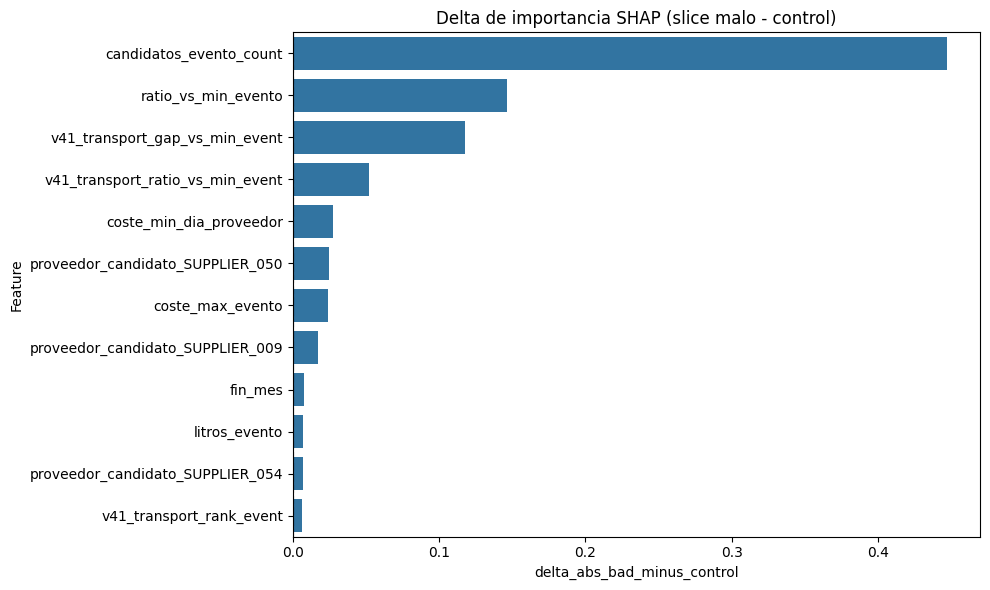

In [22]:
# Visual rápida de las features más diferenciales

top_features = shap_compare.head(12)["feature"].tolist()
plot_df = shap_compare.loc[shap_compare["feature"].isin(top_features)].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df.sort_values("delta_abs_bad_minus_control", ascending=False),
    x="delta_abs_bad_minus_control",
    y="feature",
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Delta de importancia SHAP (slice malo - control)")
plt.xlabel("delta_abs_bad_minus_control")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Lectura del SHAP focalizado

Aquí comparamos el slice malo contra un slice de control muy parecido dentro del mismo contexto operativo. La tabla no dice todavía qué regla aplicar, pero sí qué señales pesan de forma diferencial cuando el champion degrada a `SUPPLIER_050` de `rank 2` a `rank 3`.

La columna más útil en esta fase sigue siendo `delta_abs_bad_minus_control`:
- si es alta y positiva, esa feature pesa más en los casos malos que en el control;
- si además el `delta_signed_bad_minus_control` tiene una dirección estable, ya empezamos a ver también hacia dónde empuja.

### INTERPRETACIÓN

El SHAP focalizado corregido apunta a tres familias de señales:
- competencia del evento (`candidatos_evento_count`),
- posicionamiento relativo de coste (`ratio_vs_min_evento`),
- y señal de transporte relativa (`v41_transport_gap_vs_min_event`, `v41_transport_ratio_vs_min_event`, y en segundo plano `v41_transport_rank_event`).

La lectura prudente es esta:
- SHAP sí sugiere que el champion penaliza más al proveedor real cuando empeora su posición relativa frente al mínimo y cuando la señal de transporte le es adversa.
- `candidatos_evento_count` sale muy arriba en importancia diferencial, pero todavía no debemos convertirlo en threshold: primero hay que comprobar si realmente separa bien en valores reales.

Por tanto, el siguiente paso correcto es bajar de SHAP a distribuciones reales y decidir qué señales son solo importantes para el modelo y cuáles son además traducibles a una intervención operativa.


In [23]:
# Comparación de distribuciones reales bad vs control
# sobre las features que SHAP ha señalado como más diferenciales

focus_features = [
    "candidatos_evento_count",
    "ratio_vs_min_evento",
    "v41_transport_rank_event",
    "v41_transport_ratio_vs_min_event",
]

distribution_compare = (
    df_shap_positive_compare[focus_features + ["shap_segment"]]
    .groupby("shap_segment")
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(Markdown("### Comparación bad vs control · estadísticas descriptivas"))
display(distribution_compare)


### Comparación bad vs control · estadísticas descriptivas

candidatos_evento_count                                 \
                                       count      mean median       std min   
shap_segment                                                                  
bad_top2_worsens                          38  6.394737    6.0  1.174952   5   
control_not_worsened                      54  7.648148    8.0  1.151822   5   

                         ratio_vs_min_evento                                \
                     max               count      mean    median       std   
shap_segment                                                                 
bad_top2_worsens       8                  38  1.052561  1.064309  0.020075   
control_not_worsened   9                  54  1.018000  1.014286  0.010684   

                      ... v41_transport_rank_event                      \
                      ...                   median       std  min  max   
shap_segment          ...                                                
bad_top2_worsens      ...                      5.0  0.633355  4.0  6.0   
control_not_worsened  ...                      3.5  1.610261  0.0  6.0   

                     v41_transport_ratio_vs_min_event                      \
                                                count      mean    median   
shap_segment                                                                
bad_top2_worsens                                   38  1.052561  1.064309   
control_not_worsened                               54  0.979925  1.014286   

                                                    
                           std       min       max  
shap_segment                                        
bad_top2_worsens      0.020075  1.015412  1.074334  
control_not_worsened  0.194267  0.000000  1.041595  

[2 rows x 24 columns]

In [24]:
# Percentiles para pensar en thresholds operativos

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

quantile_rows = []
for segment_name, segment_df in df_shap_positive_compare.groupby("shap_segment"):
    for feature in focus_features:
        feature_quantiles = segment_df[feature].quantile(quantiles).to_dict()
        row = {
            "segment": segment_name,
            "feature": feature,
        }
        row.update({f"q{int(q*100)}": value for q, value in feature_quantiles.items()})
        quantile_rows.append(row)

quantiles_df = pd.DataFrame(quantile_rows)

display(Markdown("### Percentiles bad vs control"))
display(quantiles_df)


### Percentiles bad vs control

,segment,feature,q10,q25,q50,q75,q90
0,bad_top2_worsens,candidatos_evento_count,5.000000,5.000000,6.000000,7.000000,8.000000
1,bad_top2_worsens,ratio_vs_min_evento,1.035379,1.035969,1.064309,1.074334,1.074334
2,bad_top2_worsens,v41_transport_rank_event,5.000000,5.000000,5.000000,6.000000,6.000000
3,bad_top2_worsens,v41_transport_ratio_vs_min_event,1.035379,1.035969,1.064309,1.074334,1.074334
4,control_not_worsened,candidatos_evento_count,6.000000,8.000000,8.000000,8.000000,9.000000
5,control_not_worsened,ratio_vs_min_evento,1.006075,1.013370,1.014286,1.021664,1.036251
6,control_not_worsened,v41_transport_rank_event,2.000000,2.000000,3.500000,5.000000,5.000000
7,control_not_worsened,v41_transport_ratio_vs_min_event,1.005298,1.009258,1.014286,1.021664,1.036251


### Lectura de distribuciones bad vs control

Después del SHAP focalizado, aquí bajamos a valores reales para comprobar si las features diferenciales también se comportan como señales separables en números y rangos.

### INTERPRETACIÓN

La corrección del pipeline cambia bastante la lectura:
- `candidatos_evento_count` ya no parece buena candidata para una regla simple. Aunque SHAP la marcaba como importante, en valores reales separa mal e incluso en dirección opuesta: el control tiene más candidatos de media y mediana que el slice malo.
- `ratio_vs_min_evento` sí separa con claridad. En el slice malo, `SUPPLIER_050` aparece sistemáticamente más penalizado respecto al mínimo del evento.
- `v41_transport_rank_event` también separa bien: en el slice malo la mediana está en torno a `5`, mientras que en el control está alrededor de `3.5`.
- `v41_transport_ratio_vs_min_event` refuerza la misma historia desde la parte de transporte.

La conclusión provisional es que el patrón local del champion no parece explicarse por la complejidad general del evento, sino por una combinación de coste relativo peor + peor posicionamiento en transporte. Eso ya deja una base razonable para probar thresholds simples.


In [25]:
# Hipótesis simple de flag de baja confianza para el slice detectado

candidate_flag_df = df_shap_positive_compare.copy()

candidate_flag_df["candidate_low_conf_flag"] = (
    (candidate_flag_df["ratio_vs_min_evento"] >= 1.035)
    & (candidate_flag_df["v41_transport_rank_event"] >= 5)
).astype(int)

flag_summary = (
    candidate_flag_df.groupby(["shap_segment", "candidate_low_conf_flag"], as_index=False)
    .agg(events=("event_id", "count"))
)

flag_summary["share_within_segment"] = (
    flag_summary["events"]
    / flag_summary.groupby("shap_segment")["events"].transform("sum")
)

display(flag_summary)


,shap_segment,candidate_low_conf_flag,events,share_within_segment
0,bad_top2_worsens,0,6,0.157895
1,bad_top2_worsens,1,32,0.842105
2,control_not_worsened,0,50,0.925926
3,control_not_worsened,1,4,0.074074


### Thresholds operativos candidatos


In [26]:
# Validación inferencia-visible de la flag candidata
# Aquí la flag ya no usa proveedor_real ni baseline.
# Solo usa señales disponibles en inferencia + salida del champion puro.

flag_ratio_threshold = 1.035
flag_transport_rank_threshold = 5

# Enriquecemos el universo de candidatas del holdout con:
# - ranking/score del champion
# - top1 del champion a nivel evento
# - etiqueta de evaluación (solo para medir después, no para definir la flag)

df_flag_candidates = (
    df_holdout_candidates
    .merge(
        df_preds_pure_champion[
            [
                "event_id",
                "proveedor_candidato",
                "score_pure_champion",
                "rank_pure_champion",
                "is_top1_pure_champion",
                "is_top2_pure_champion",
            ]
        ],
        on=["event_id", "proveedor_candidato"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        df_event_compare[
            [
                "event_id",
                "top1_provider_pure_champion",
                "top2_result_vs_baseline",
            ]
        ],
        on="event_id",
        how="inner",
        validate="many_to_one",
    )
    .copy()
)

# Flag candidata visible en inferencia:
# - mismo slice operativo
# - fila candidata SUPPLIER_050
# - champion predice SUPPLIER_009 como top1
# - señales numéricas que separaron bad vs control
df_flag_candidates["candidate_low_conf_flag"] = (
    (df_flag_candidates["producto_canonico"] == focus_pattern["producto_canonico"])
    & (df_flag_candidates["terminal_compra"] == focus_pattern["terminal_compra"])
    & (df_flag_candidates["proveedor_candidato"] == focus_pattern["proveedor_real"])
    & (df_flag_candidates["top1_provider_pure_champion"] == focus_pattern["top1_provider_pure_champion"])
    & (df_flag_candidates["ratio_vs_min_evento"] >= flag_ratio_threshold)
    & (df_flag_candidates["v41_transport_rank_event"] >= flag_transport_rank_threshold)
).astype(int)

# Agregamos a nivel evento para ver si el evento quedaría marcado
df_event_low_conf = (
    df_flag_candidates.groupby("event_id", as_index=False)
    .agg(
        fecha_evento=("fecha_evento", "first"),
        producto_canonico=("producto_canonico", "first"),
        terminal_compra=("terminal_compra", "first"),
        top1_provider_pure_champion=("top1_provider_pure_champion", "first"),
        candidate_low_conf_flag=("candidate_low_conf_flag", "max"),
        flagged_candidates=("candidate_low_conf_flag", "sum"),
        top2_result_vs_baseline=("top2_result_vs_baseline", "first"),
    )
)

# Segmentos de evaluación: solo para medir cómo separa la flag
df_event_low_conf["eval_segment"] = np.select(
    [
        df_event_low_conf["event_id"].isin(bad_event_ids),
        df_event_low_conf["event_id"].isin(control_event_ids),
    ],
    [
        "bad_top2_worsens",
        "control_not_worsened",
    ],
    default="other_holdout",
)

flag_eval_summary = (
    df_event_low_conf.loc[
        df_event_low_conf["eval_segment"].isin(["bad_top2_worsens", "control_not_worsened"])
    ]
    .groupby(["eval_segment", "candidate_low_conf_flag"], as_index=False)
    .agg(events=("event_id", "count"))
)

flag_eval_summary["share_within_segment"] = (
    flag_eval_summary["events"]
    / flag_eval_summary.groupby("eval_segment")["events"].transform("sum")
)

display(Markdown("### Evaluación de la flag en modo inferencia-visible"))
display(flag_eval_summary)

# Qué volumen tendría la flag en el universo observable del mismo slice operativo
observable_universe = (
    df_flag_candidates.loc[
        (df_flag_candidates["producto_canonico"] == focus_pattern["producto_canonico"])
        & (df_flag_candidates["terminal_compra"] == focus_pattern["terminal_compra"])
        & (df_flag_candidates["proveedor_candidato"] == focus_pattern["proveedor_real"])
        & (df_flag_candidates["top1_provider_pure_champion"] == focus_pattern["top1_provider_pure_champion"])
    ]
    .copy()
)

observable_universe_summary = (
    observable_universe.groupby("candidate_low_conf_flag", as_index=False)
    .agg(rows=("event_id", "count"), unique_events=("event_id", "nunique"))
)

observable_universe_summary["share_rows"] = (
    observable_universe_summary["rows"] / observable_universe_summary["rows"].sum()
)
observable_universe_summary["share_events"] = (
    observable_universe_summary["unique_events"] / observable_universe_summary["unique_events"].sum()
)

display(Markdown("### Volumen de la flag en el universo observable del slice"))
display(observable_universe_summary)

display(Markdown("### Ejemplos de eventos marcados por la flag"))
display(
    df_event_low_conf.loc[
        (df_event_low_conf["candidate_low_conf_flag"] == 1)
        & (df_event_low_conf["eval_segment"].isin(["bad_top2_worsens", "control_not_worsened"]))
    ][
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "top1_provider_pure_champion",
            "candidate_low_conf_flag",
            "eval_segment",
            "top2_result_vs_baseline",
        ]
    ].sort_values(["eval_segment", "fecha_evento", "event_id"]).head(20)
)


### Evaluación de la flag en modo inferencia-visible

,eval_segment,candidate_low_conf_flag,events,share_within_segment
0,bad_top2_worsens,0,6,0.157895
1,bad_top2_worsens,1,32,0.842105
2,control_not_worsened,0,50,0.925926
3,control_not_worsened,1,4,0.074074


### Volumen de la flag en el universo observable del slice

,candidate_low_conf_flag,rows,unique_events,share_rows,share_events
0,0,1174,1174,0.74587,0.74587
1,1,400,400,0.25413,0.25413


### Ejemplos de eventos marcados por la flag

,event_id,fecha_evento,producto_canonico,terminal_compra,top1_provider_pure_champion,candidate_low_conf_flag,eval_segment,top2_result_vs_baseline
165,EVENT_0EBE8CB0DD99,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
208,EVENT_140BD9271083,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
299,EVENT_1D1EB6749B35,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
385,EVENT_242162EF40F3,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
622,EVENT_38F915D22AAB,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
1459,EVENT_8E3DB77FF24E,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
2000,EVENT_BFA5DE66EB11,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
2151,EVENT_CD80806C2D5E,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
2461,EVENT_ED1E0D89DE25,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens
236,EVENT_16DFC3581344,2029-06-18,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1,bad_top2_worsens,champion_worsens


### Lectura de la flag en modo inferencia-visible

Aquí damos el paso importante de traducir la hipótesis a un formato observable en inferencia. La flag ya no usa información futura, sino solo señales visibles en producción: contexto del evento, proveedor candidato, top1 del champion y variables derivadas del propio ranking.

### INTERPRETACIÓN

La separación se mantiene bien al pasar a modo inferencia-visible:
- la flag captura `32` de `38` casos malos (`84.2%`),
- y solo se activa en `4` de `54` casos del control estricto (`7.4%`).

Además, la flag se activa en alrededor del `25.4%` del universo observable de este slice. Eso sigue siendo demasiado amplio para pensar en un override duro automático, pero ya es bastante defendible como marca operativa de baja confianza.

La conclusión provisional es que esta señal ha sobrevivido a los dos filtros importantes del notebook:
- explicabilidad local,
- y traducción a espacio observable en inferencia.

Por tanto, el siguiente paso lógico es medir si esa flag no solo identifica patrón, sino que realmente concentra riesgo y si una intervención local sobre eventos marcados compensa frente al champion puro.


In [27]:
# Enriquecimiento de riesgo dentro del universo observable del slice

observable_event_universe = df_event_low_conf.loc[
    (df_event_low_conf["producto_canonico"] == focus_pattern["producto_canonico"])
    & (df_event_low_conf["terminal_compra"] == focus_pattern["terminal_compra"])
    & (df_event_low_conf["top1_provider_pure_champion"] == focus_pattern["top1_provider_pure_champion"])
].copy()

observable_event_universe["actual_bad"] = (
    observable_event_universe["top2_result_vs_baseline"] == "champion_worsens"
).astype(int)

risk_by_flag = (
    observable_event_universe.groupby("candidate_low_conf_flag", as_index=False)
    .agg(
        events=("event_id", "count"),
        actual_bad_events=("actual_bad", "sum"),
    )
)

risk_by_flag["bad_rate"] = risk_by_flag["actual_bad_events"] / risk_by_flag["events"]

base_bad_rate = observable_event_universe["actual_bad"].mean()
risk_by_flag["base_bad_rate"] = base_bad_rate
risk_by_flag["lift_vs_base"] = risk_by_flag["bad_rate"] / base_bad_rate

display(Markdown("### Riesgo de `champion_worsens` dentro del universo observable"))
display(risk_by_flag)

print("Base bad rate:", round(base_bad_rate, 6))


### Riesgo de `champion_worsens` dentro del universo observable

,candidate_low_conf_flag,events,actual_bad_events,bad_rate,base_bad_rate,lift_vs_base
0,0,1174,6,0.005111,0.024142,0.211692
1,1,400,32,0.080000,0.024142,3.313684


Base bad rate: 0.024142


### Lectura del enriquecimiento de riesgo

La flag no solo identifica el patrón, sino que además concentra riesgo de forma clara dentro del universo observable del slice. Cuando la flag no se activa, la tasa de `champion_worsens` cae a `0.51%`; cuando se activa, sube a `8.00%`, lo que supone un `lift` de `3.31x` sobre la tasa base (`2.41%`).

Eso hace que la hipótesis sea bastante sólida como marca de baja confianza. Aun así, la tasa absoluta de error dentro de los eventos marcados sigue siendo limitada en términos de intervención automática: la mayoría de los eventos marcados no terminan en `champion_worsens`.

La lectura prudente sigue siendo:
- no es una regla determinista dura,
- sí es una señal operativa seria,
- y ya justifica una simulación local de fallback para medir si convertir la señal en micropolítica aporta valor real.


In [28]:
# Simulación de fallback local al baseline cuando la flag se activa
# Objetivo:
# - si candidate_low_conf_flag = 1 -> usar baseline
# - si candidate_low_conf_flag = 0 -> usar champion puro

df_event_simulation = (
    df_event_compare.merge(
        df_event_low_conf[["event_id", "candidate_low_conf_flag"]],
        on="event_id",
        how="left",
        validate="one_to_one",
    )
    .copy()
)

df_event_simulation["candidate_low_conf_flag"] = (
    df_event_simulation["candidate_low_conf_flag"]
    .fillna(0)
    .astype(int)
)

# Fuente elegida por la simulación
df_event_simulation["sim_source"] = np.where(
    df_event_simulation["candidate_low_conf_flag"] == 1,
    "baseline",
    "pure_champion",
)

# Predicción simulada
df_event_simulation["sim_top1_provider"] = np.where(
    df_event_simulation["candidate_low_conf_flag"] == 1,
    df_event_simulation["top1_provider_baseline"],
    df_event_simulation["top1_provider_pure_champion"],
)

df_event_simulation["sim_top1_hit"] = np.where(
    df_event_simulation["candidate_low_conf_flag"] == 1,
    df_event_simulation["top1_hit_baseline"],
    df_event_simulation["top1_hit_pure_champion"],
).astype(int)

df_event_simulation["sim_top2_hit"] = np.where(
    df_event_simulation["candidate_low_conf_flag"] == 1,
    df_event_simulation["top2_hit_baseline"],
    df_event_simulation["top2_hit_pure_champion"],
).astype(int)

# Comparativa global
simulation_summary = pd.DataFrame(
    [
        {
            "strategy": "baseline",
            "top1_hit": df_event_simulation["top1_hit_baseline"].mean(),
            "top2_hit": df_event_simulation["top2_hit_baseline"].mean(),
            "events": len(df_event_simulation),
        },
        {
            "strategy": "pure_champion",
            "top1_hit": df_event_simulation["top1_hit_pure_champion"].mean(),
            "top2_hit": df_event_simulation["top2_hit_pure_champion"].mean(),
            "events": len(df_event_simulation),
        },
        {
            "strategy": "flagged_fallback_to_baseline",
            "top1_hit": df_event_simulation["sim_top1_hit"].mean(),
            "top2_hit": df_event_simulation["sim_top2_hit"].mean(),
            "events": len(df_event_simulation),
        },
    ]
)

simulation_summary["delta_top1_vs_champion"] = (
    simulation_summary["top1_hit"]
    - simulation_summary.loc[simulation_summary["strategy"] == "pure_champion", "top1_hit"].iloc[0]
)

simulation_summary["delta_top2_vs_champion"] = (
    simulation_summary["top2_hit"]
    - simulation_summary.loc[simulation_summary["strategy"] == "pure_champion", "top2_hit"].iloc[0]
)

display(Markdown("### Simulación global · fallback local al baseline"))
display(simulation_summary)

# Efecto solo en eventos marcados por la flag
flagged_events = df_event_simulation.loc[
    df_event_simulation["candidate_low_conf_flag"] == 1
].copy()

flagged_effect_summary = pd.DataFrame(
    [
        {
            "scope": "flagged_events_only",
            "events": len(flagged_events),
            "champion_top1_hit": flagged_events["top1_hit_pure_champion"].mean(),
            "baseline_top1_hit": flagged_events["top1_hit_baseline"].mean(),
            "champion_top2_hit": flagged_events["top2_hit_pure_champion"].mean(),
            "baseline_top2_hit": flagged_events["top2_hit_baseline"].mean(),
        }
    ]
)

display(Markdown("### Efecto dentro de los eventos marcados"))
display(flagged_effect_summary)

# Conteo de ayuda / daño de la simulación frente al champion puro
df_event_simulation["sim_vs_champion_top1"] = np.select(
    [
        (df_event_simulation["top1_hit_pure_champion"] == 0) & (df_event_simulation["sim_top1_hit"] == 1),
        (df_event_simulation["top1_hit_pure_champion"] == 1) & (df_event_simulation["sim_top1_hit"] == 0),
        (df_event_simulation["top1_hit_pure_champion"] == df_event_simulation["sim_top1_hit"]),
    ],
    [
        "sim_improves",
        "sim_harms",
        "same_result",
    ],
    default="unknown",
)

df_event_simulation["sim_vs_champion_top2"] = np.select(
    [
        (df_event_simulation["top2_hit_pure_champion"] == 0) & (df_event_simulation["sim_top2_hit"] == 1),
        (df_event_simulation["top2_hit_pure_champion"] == 1) & (df_event_simulation["sim_top2_hit"] == 0),
        (df_event_simulation["top2_hit_pure_champion"] == df_event_simulation["sim_top2_hit"]),
    ],
    [
        "sim_improves",
        "sim_harms",
        "same_result",
    ],
    default="unknown",
)

sim_effect_top1 = (
    df_event_simulation["sim_vs_champion_top1"]
    .value_counts(dropna=False)
    .rename_axis("sim_vs_champion_top1")
    .reset_index(name="events")
)
sim_effect_top1["share"] = sim_effect_top1["events"] / len(df_event_simulation)

sim_effect_top2 = (
    df_event_simulation["sim_vs_champion_top2"]
    .value_counts(dropna=False)
    .rename_axis("sim_vs_champion_top2")
    .reset_index(name="events")
)
sim_effect_top2["share"] = sim_effect_top2["events"] / len(df_event_simulation)

display(Markdown("### Efecto de la simulación vs champion puro · Top-1"))
display(sim_effect_top1)

display(Markdown("### Efecto de la simulación vs champion puro · Top-2"))
display(sim_effect_top2)

# Casos concretos donde la simulación mejora o daña al champion
display(Markdown("### Ejemplos donde la simulación mejora al champion en Top-2"))
display(
    df_event_simulation.loc[df_event_simulation["sim_vs_champion_top2"] == "sim_improves", [
        "event_id",
        "fecha_evento",
        "producto_canonico",
        "terminal_compra",
        "proveedor_real",
        "candidate_low_conf_flag",
        "top1_provider_baseline",
        "top1_provider_pure_champion",
        "top2_hit_baseline",
        "top2_hit_pure_champion",
        "sim_top2_hit",
        "top2_result_vs_baseline",
    ]].sort_values(["fecha_evento", "event_id"]).head(20)
)

### Simulación global · fallback local al baseline

,strategy,top1_hit,top2_hit,events,delta_top1_vs_champion,delta_top2_vs_champion
0,baseline,0.764527,0.858336,2633,-0.007976,-0.024307
1,pure_champion,0.772503,0.882643,2633,0.000000,0.000000
2,flagged_fallback_to_baseline,0.772503,0.889859,2633,0.000000,0.007216


### Efecto dentro de los eventos marcados

,scope,events,champion_top1_hit,baseline_top1_hit,champion_top2_hit,baseline_top2_hit
0,flagged_events_only,400,0.7375,0.7375,0.78,0.8275


### Efecto de la simulación vs champion puro · Top-1

,sim_vs_champion_top1,events,share
0,same_result,2633,1.0


### Efecto de la simulación vs champion puro · Top-2

,sim_vs_champion_top2,events,share
0,same_result,2588,0.982909
1,sim_improves,32,0.012153
2,sim_harms,13,0.004937


### Ejemplos donde la simulación mejora al champion en Top-2

,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_real,candidate_low_conf_flag,top1_provider_baseline,top1_provider_pure_champion,top2_hit_baseline,top2_hit_pure_champion,sim_top2_hit,top2_result_vs_baseline
165,EVENT_0EBE8CB0DD99,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
208,EVENT_140BD9271083,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
299,EVENT_1D1EB6749B35,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
385,EVENT_242162EF40F3,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
622,EVENT_38F915D22AAB,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
1459,EVENT_8E3DB77FF24E,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
2000,EVENT_BFA5DE66EB11,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
2151,EVENT_CD80806C2D5E,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
2461,EVENT_ED1E0D89DE25,2029-06-16,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens
236,EVENT_16DFC3581344,2029-06-18,PRODUCT_003,TERMINAL_001,SUPPLIER_050,1,SUPPLIER_009,SUPPLIER_009,1,0,1,champion_worsens


### Lectura de la simulación de fallback local

Aquí ya no estamos solo explicando el modelo, sino probando una intervención concreta: en los eventos marcados por la flag de baja confianza, sustituimos la recomendación del champion por la del baseline.

La simulación corregida es materialmente mejor de lo que sugería el análisis anterior:
- no cambia nada en Top-1 global (`0.772503` antes y después),
- mejora el Top-2 global de `0.882643` a `0.889859` (`+0.007216`),
- y dentro de los eventos marcados el baseline supera al champion en Top-2 (`0.8275` vs `0.7800`).

Además, frente al champion puro la simulación:
- mejora `32` eventos en Top-2,
- daña `13`,
- y deja el resto igual.

La lectura correcta ya no es solo “hallazgo explicativo”. Esto empieza a parecer un candidato serio para una micropolítica local o un fallback selectivo al baseline dentro de este slice. Aun así, todavía no es una decisión de producción: antes habría que validarlo con el gate formal de postinferencia y medir explícitamente coherencia y no-harm en un bloque operativo separado.


In [29]:
# Auditoría detallada de un evento concreto a nivel candidata
# Cambia este event_id para inspeccionar casos representativos del análisis.

event_id_to_audit = "0666cb94a516586dc9b6c86f24eb73d3607402be"

df_event_audit = (
    df_compare_candidates.loc[df_compare_candidates["event_id"] == event_id_to_audit]
    .sort_values("rank_pure_champion")
    .reset_index(drop=True)
)

display(
    df_event_audit[
        [
            "event_id",
            "fecha_evento",
            "producto_canonico",
            "terminal_compra",
            "proveedor_candidato",
            master_spec["target_col"],
            "score_baseline",
            "rank_baseline",
            "score_pure_champion",
            "rank_pure_champion",
            "coste_min_dia_proveedor",
            "delta_vs_min_evento",
            "ratio_vs_min_evento",
        ]
    ]
)

,event_id,fecha_evento,producto_canonico,terminal_compra,proveedor_candidato,target_elegido,score_baseline,rank_baseline,score_pure_champion,rank_pure_champion,coste_min_dia_proveedor,delta_vs_min_evento,ratio_vs_min_evento


### Lectura de auditoría manual del evento

Esta celda no busca detectar patrones globales, sino inspeccionar un evento concreto a nivel candidata para ver cómo baseline y champion ordenan a los proveedores. Es útil para poner cara real a una slice ya detectada y comprobar si el patrón agregado se entiende también en un caso individual.

### INTEPRETACIÓN

Este evento confirma bien el patrón detectado en la slice dominante. Tanto baseline como champion recomiendan `SUPPLIER_009` como top1, así que el problema no está en la primera posición. La diferencia aparece en el segundo puesto: el baseline deja a `SUPPLIER_050` en `rank 2`, mientras que el champion lo baja a `rank 3` y sube a `SUPPLIER_019`.

En valores concretos se ve que `SUPPLIER_050` está claramente peor que el mínimo del evento (`ratio_vs_min_evento = 1.035969`), mientras `SUPPLIER_019` es el mínimo y `SUPPLIER_009` está prácticamente empatado. La lectura operativa es que el champion está penalizando más de lo necesario a `SUPPLIER_050` en este contexto y lo saca del Top-2, mientras que el baseline conserva mejor esa segunda posición. Este caso no prueba una regla por sí solo, pero sí ilustra muy bien la lógica de la flag de baja confianza y del posible fallback local al baseline.

### BACKLOG

- Utilizar esta auditoría manual para buscar en conjunción con el administrativo y la ayuda de CODEX para poder encontrar patrones.


## SHAP global para narrativa y portfolio

Después del SHAP focalizado, dejamos una lectura global del champion puro. Esta parte no pretende justificar una policy: sirve para mostrar qué familias de señal mueven más el modelo en conjunto y dejar una pieza limpia de presentación y portfolio.


In [30]:
# SHAP global del champion puro sobre el holdout
# Grano: filas candidatas del holdout

global_shap_max_rows = 5000
global_shap_random_state = 42

if len(X_holdout_pure_champion) > global_shap_max_rows:
    global_shap_sample_idx = (
        X_holdout_pure_champion
        .sample(n=global_shap_max_rows, random_state=global_shap_random_state)
        .index
    )
else:
    global_shap_sample_idx = X_holdout_pure_champion.index

X_shap_global = X_holdout_pure_champion.loc[global_shap_sample_idx].copy()
df_shap_global = df_holdout_candidates.loc[global_shap_sample_idx].copy()

print("Rows holdout champion matrix:", len(X_holdout_pure_champion))
print("Rows used for global SHAP:", len(X_shap_global))


Rows holdout champion matrix: 20852
Rows used for global SHAP: 5000


In [31]:
# Cálculo de SHAP global para el champion puro

import shap

global_explainer = shap.TreeExplainer(pure_champion_model)
global_shap_raw = global_explainer.shap_values(X_shap_global)

if isinstance(global_shap_raw, list):
    global_shap_values = global_shap_raw[1] if len(global_shap_raw) > 1 else global_shap_raw[0]
else:
    global_shap_values = global_shap_raw

global_shap_values = np.asarray(global_shap_values)

print("SHAP matrix shape:", global_shap_values.shape)
print("Feature matrix shape:", X_shap_global.shape)


SHAP matrix shape: (5000, 79)
Feature matrix shape: (5000, 79)


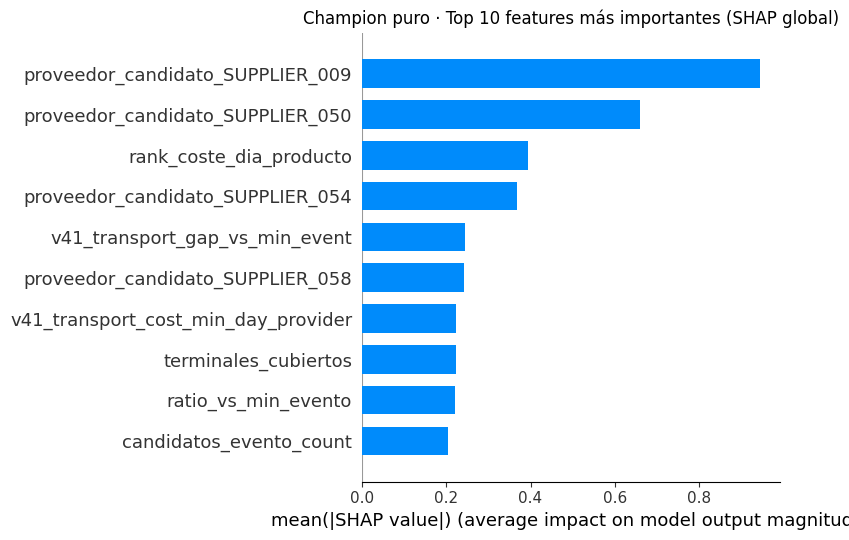

In [32]:
# SHAP global · top 10 features más importantes (imagen para slide)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    global_shap_values,
    X_shap_global,
    plot_type="bar",
    max_display=10,
    show=False,
)
plt.title("Champion puro · Top 10 features más importantes (SHAP global)")
plt.tight_layout()
plt.show()


In [33]:
# Tabla top 10 SHAP global para acompañar la slide

global_shap_importance = pd.DataFrame({
    "feature": X_shap_global.columns,
    "mean_abs_shap": np.abs(global_shap_values).mean(axis=0),
    "mean_signed_shap": global_shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

display(global_shap_importance.head(10))


,feature,mean_abs_shap,mean_signed_shap
0,proveedor_candidato_SUPPLIER_009,0.944715,0.183148
1,proveedor_candidato_SUPPLIER_050,0.659144,0.114378
2,rank_coste_dia_producto,0.395058,0.242789
3,proveedor_candidato_SUPPLIER_054,0.367293,-0.017765
4,v41_transport_gap_vs_min_event,0.244725,-0.145187
5,proveedor_candidato_SUPPLIER_058,0.242064,0.242064
6,v41_transport_cost_min_day_provider,0.223829,0.182172
7,terminales_cubiertos,0.223443,0.030421
8,ratio_vs_min_evento,0.220037,-0.004732
9,candidatos_evento_count,0.203307,-0.180199


### Lectura del SHAP global del champion puro

A diferencia del SHAP focalizado, que sirve para explicar una slice concreta de error, este SHAP global resume qué señales pesan más en el champion puro sobre el holdout en general. Su utilidad principal aquí es narrativa y de portfolio: deja una imagen clara de cuáles son las variables que más mueven el modelo.

La lectura correcta de esta slide no es “estas son las reglas del modelo”, sino “estas son las familias de señal a las que el champion está prestando más atención”. Después, esa lectura global se complementa con el SHAP focalizado, que es el que realmente permite entender por qué una slice concreta empeora o mejora.

### PRODUCT_005 · patrón local antes de simular fallback

Aquí no buscamos explicabilidad con SHAP, sino comprobar si el deterioro fuerte de `Top-1` en `PRODUCT_005` se concentra en un patrón operativo limpio. Si la pérdida de `Top-1` está bien delimitada y `Top-2` no sufre, entonces `PRODUCT_005` deja de ser una slice descriptiva y pasa a ser candidata seria a fallback local.


In [34]:
# Profundización PRODUCT_005

df_go_c = (
    df_event_compare.loc[df_event_compare["producto_canonico"] == "PRODUCT_005"]
    .copy()
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

print("Eventos PRODUCT_005:", len(df_go_c))

go_c_summary_top1 = (
    df_go_c["top1_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top1_result_vs_baseline")
    .reset_index(name="event_count")
)
go_c_summary_top1["share"] = go_c_summary_top1["event_count"] / len(df_go_c)

go_c_summary_top2 = (
    df_go_c["top2_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top2_result_vs_baseline")
    .reset_index(name="event_count")
)
go_c_summary_top2["share"] = go_c_summary_top2["event_count"] / len(df_go_c)

display(Markdown("### PRODUCT_005 · resumen Top-1"))
display(go_c_summary_top1)

display(Markdown("### PRODUCT_005 · resumen Top-2"))
display(go_c_summary_top2)


Eventos PRODUCT_005: 100


### PRODUCT_005 · resumen Top-1

,top1_result_vs_baseline,event_count,share
0,both_hit,77,0.77
1,champion_worsens,19,0.19
2,both_fail,4,0.04


### PRODUCT_005 · resumen Top-2

,top2_result_vs_baseline,event_count,share
0,both_hit,98,0.98
1,champion_improves,2,0.02


In [35]:
# PRODUCT_005 · concentración por terminal + proveedor real + top1 baseline/champion

go_c_pattern_slice = (
    df_go_c.groupby(
        [
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
        ],
        as_index=False,
    )
    .agg(
        events=("event_id", "count"),
        top1_hit_baseline=("top1_hit_baseline", "mean"),
        top1_hit_pure_champion=("top1_hit_pure_champion", "mean"),
        top2_hit_baseline=("top2_hit_baseline", "mean"),
        top2_hit_pure_champion=("top2_hit_pure_champion", "mean"),
        mean_rank_real_baseline=("rank_real_baseline", "mean"),
        mean_rank_real_pure_champion=("rank_real_pure_champion", "mean"),
        mean_delta_rank_real=("delta_rank_real_champion_vs_baseline", "mean"),
        mean_candidates=("candidatos_evento_count", "mean"),
        mean_spread=("spread_coste_holdout_evento", "mean"),
    )
    .sort_values(["events", "mean_delta_rank_real"], ascending=[False, False])
    .reset_index(drop=True)
)

display(go_c_pattern_slice.head(20))


,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,events,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,mean_rank_real_baseline,mean_rank_real_pure_champion,mean_delta_rank_real,mean_candidates,mean_spread
0,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,77,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.220779,27.249714
1,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,15,1.0,0.0,1.0,1.0,1.0,2.0,1.0,3.000000,31.164667
2,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,4,1.0,0.0,1.0,1.0,1.0,2.0,1.0,4.000000,30.274000
3,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,0.0,0.0,1.0,1.0,2.0,2.0,0.0,3.000000,25.190000
4,TERMINAL_001,SUPPLIER_019,SUPPLIER_009,SUPPLIER_009,2,0.0,0.0,0.0,1.0,3.0,2.0,-1.0,3.000000,20.340000


## Hallazgos operativos principales

### PRODUCT_005 · fallback local candidato

La pregunta aquí ya no es explicativa sino operativa: si hacemos fallback al baseline en el patrón `PRODUCT_005` donde el champion se va a `SUPPLIER_050` y el baseline mantiene `SUPPLIER_009`, ¿ganamos `Top-1` sin romper `Top-2`?


In [36]:
# PRODUCT_005 · fallback selectivo al baseline
# Política simulada:
# si producto = PRODUCT_005 y baseline dice SUPPLIER_009 mientras champion dice SUPPLIER_050,
# usamos baseline en lugar del champion.

df_go_c_policy = df_event_compare.copy()

df_go_c_policy["go_c_fallback_flag"] = (
    (df_go_c_policy["producto_canonico"] == "PRODUCT_005")
    & (df_go_c_policy["top1_provider_baseline"] == "SUPPLIER_009")
    & (df_go_c_policy["top1_provider_pure_champion"] == "SUPPLIER_050")
).astype(int)

print("Eventos marcados PRODUCT_005:", df_go_c_policy["go_c_fallback_flag"].sum())
print("Share PRODUCT_005 marcado:", round(df_go_c_policy["go_c_fallback_flag"].mean(), 6))

# Predicción simulada
df_go_c_policy["go_c_sim_top1_hit"] = np.where(
    df_go_c_policy["go_c_fallback_flag"] == 1,
    df_go_c_policy["top1_hit_baseline"],
    df_go_c_policy["top1_hit_pure_champion"],
).astype(int)

df_go_c_policy["go_c_sim_top2_hit"] = np.where(
    df_go_c_policy["go_c_fallback_flag"] == 1,
    df_go_c_policy["top2_hit_baseline"],
    df_go_c_policy["top2_hit_pure_champion"],
).astype(int)

go_c_simulation_summary = pd.DataFrame(
    [
        {
            "strategy": "baseline",
            "top1_hit": df_go_c_policy["top1_hit_baseline"].mean(),
            "top2_hit": df_go_c_policy["top2_hit_baseline"].mean(),
            "events": len(df_go_c_policy),
        },
        {
            "strategy": "pure_champion",
            "top1_hit": df_go_c_policy["top1_hit_pure_champion"].mean(),
            "top2_hit": df_go_c_policy["top2_hit_pure_champion"].mean(),
            "events": len(df_go_c_policy),
        },
        {
            "strategy": "go_c_fallback_to_baseline",
            "top1_hit": df_go_c_policy["go_c_sim_top1_hit"].mean(),
            "top2_hit": df_go_c_policy["go_c_sim_top2_hit"].mean(),
            "events": len(df_go_c_policy),
        },
    ]
)

go_c_simulation_summary["delta_top1_vs_champion"] = (
    go_c_simulation_summary["top1_hit"]
    - go_c_simulation_summary.loc[
        go_c_simulation_summary["strategy"] == "pure_champion", "top1_hit"
    ].iloc[0]
)

go_c_simulation_summary["delta_top2_vs_champion"] = (
    go_c_simulation_summary["top2_hit"]
    - go_c_simulation_summary.loc[
        go_c_simulation_summary["strategy"] == "pure_champion", "top2_hit"
    ].iloc[0]
)

display(Markdown("### PRODUCT_005 · simulación global"))
display(go_c_simulation_summary)

# Efecto solo en eventos marcados
go_c_flagged = df_go_c_policy.loc[df_go_c_policy["go_c_fallback_flag"] == 1].copy()

go_c_flagged_summary = pd.DataFrame(
    [
        {
            "scope": "go_c_flagged_only",
            "events": len(go_c_flagged),
            "champion_top1_hit": go_c_flagged["top1_hit_pure_champion"].mean(),
            "baseline_top1_hit": go_c_flagged["top1_hit_baseline"].mean(),
            "champion_top2_hit": go_c_flagged["top2_hit_pure_champion"].mean(),
            "baseline_top2_hit": go_c_flagged["top2_hit_baseline"].mean(),
        }
    ]
)

display(Markdown("### PRODUCT_005 · efecto dentro de eventos marcados"))
display(go_c_flagged_summary)

# Ayuda / daño frente al champion
df_go_c_policy["go_c_sim_vs_champion_top1"] = np.select(
    [
        (df_go_c_policy["top1_hit_pure_champion"] == 0) & (df_go_c_policy["go_c_sim_top1_hit"] == 1),
        (df_go_c_policy["top1_hit_pure_champion"] == 1) & (df_go_c_policy["go_c_sim_top1_hit"] == 0),
        (df_go_c_policy["top1_hit_pure_champion"] == df_go_c_policy["go_c_sim_top1_hit"]),
    ],
    ["sim_improves", "sim_harms", "same_result"],
    default="unknown",
)

df_go_c_policy["go_c_sim_vs_champion_top2"] = np.select(
    [
        (df_go_c_policy["top2_hit_pure_champion"] == 0) & (df_go_c_policy["go_c_sim_top2_hit"] == 1),
        (df_go_c_policy["top2_hit_pure_champion"] == 1) & (df_go_c_policy["go_c_sim_top2_hit"] == 0),
        (df_go_c_policy["top2_hit_pure_champion"] == df_go_c_policy["go_c_sim_top2_hit"]),
    ],
    ["sim_improves", "sim_harms", "same_result"],
    default="unknown",
)

display(Markdown("### PRODUCT_005 · Top-1 ayuda/daño vs champion"))
display(
    df_go_c_policy["go_c_sim_vs_champion_top1"]
    .value_counts(dropna=False)
    .rename_axis("go_c_sim_vs_champion_top1")
    .reset_index(name="events")
)

display(Markdown("### PRODUCT_005 · Top-2 ayuda/daño vs champion"))
display(
    df_go_c_policy["go_c_sim_vs_champion_top2"]
    .value_counts(dropna=False)
    .rename_axis("go_c_sim_vs_champion_top2")
    .reset_index(name="events")
)


Eventos marcados PRODUCT_005: 19
Share PRODUCT_005 marcado: 0.007216


### PRODUCT_005 · simulación global

,strategy,top1_hit,top2_hit,events,delta_top1_vs_champion,delta_top2_vs_champion
0,baseline,0.764527,0.858336,2633,-0.007976,-0.024307
1,pure_champion,0.772503,0.882643,2633,0.000000,0.000000
2,go_c_fallback_to_baseline,0.779719,0.882643,2633,0.007216,0.000000


### PRODUCT_005 · efecto dentro de eventos marcados

,scope,events,champion_top1_hit,baseline_top1_hit,champion_top2_hit,baseline_top2_hit
0,go_c_flagged_only,19,0.0,1.0,1.0,1.0


### PRODUCT_005 · Top-1 ayuda/daño vs champion

,go_c_sim_vs_champion_top1,events
0,same_result,2614
1,sim_improves,19


### PRODUCT_005 · Top-2 ayuda/daño vs champion

,go_c_sim_vs_champion_top2,events
0,same_result,2633


### PRODUCT_005 · interpretación de la simulación

La slice `PRODUCT_005` deja una de las señales más limpias del notebook. Al hacer fallback al baseline cuando el producto es `PRODUCT_005`, el baseline recomienda `SUPPLIER_009` y el champion recomienda `SUPPLIER_050`, la métrica global `Top-1` sube en `+0.007216` y `Top-2` no empeora.

Además, dentro de los `19` eventos marcados, el patrón es completamente limpio: el champion falla siempre en `Top-1`, el baseline acierta siempre, y ambos mantienen `Top-2 = 1.0`. La lectura operativa es que `PRODUCT_005` ya no es solo una slice explicativa, sino un candidato serio a micropolítica local de fallback selectivo.


### PRODUCT_003 residual · bolsa de complementariedad

Después de aislar el slice dominante ya explicado con SHAP, queda un residual de `PRODUCT_003` donde conviven ayuda y daño. Aquí la pregunta es distinta: si el residual no deja una regla limpia, la lectura correcta pasa a ser complementariedad baseline/champion más que fallback simple.


In [37]:
# PRODUCT_003 · separar slice dominante ya estudiado del resto

dominant_go_b_event_ids = set(df_top2_worsens_focus["event_id"])

df_go_b = (
    df_event_compare.loc[df_event_compare["producto_canonico"] == "PRODUCT_003"]
    .copy()
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

df_go_b_residual = (
    df_go_b.loc[~df_go_b["event_id"].isin(dominant_go_b_event_ids)]
    .copy()
    .reset_index(drop=True)
)

print("Eventos PRODUCT_003 total:", len(df_go_b))
print("Eventos PRODUCT_003 slice dominante:", len(df_go_b.loc[df_go_b['event_id'].isin(dominant_go_b_event_ids)]))
print("Eventos PRODUCT_003 residual:", len(df_go_b_residual))


Eventos PRODUCT_003 total: 1702
Eventos PRODUCT_003 slice dominante: 38
Eventos PRODUCT_003 residual: 1664


In [38]:
# PRODUCT_003 residual · resumen baseline vs champion

go_b_residual_summary_top1 = (
    df_go_b_residual["top1_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top1_result_vs_baseline")
    .reset_index(name="event_count")
)
go_b_residual_summary_top1["share"] = (
    go_b_residual_summary_top1["event_count"] / len(df_go_b_residual)
)

go_b_residual_summary_top2 = (
    df_go_b_residual["top2_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top2_result_vs_baseline")
    .reset_index(name="event_count")
)
go_b_residual_summary_top2["share"] = (
    go_b_residual_summary_top2["event_count"] / len(df_go_b_residual)
)

display(Markdown("### PRODUCT_003 residual · resumen Top-1"))
display(go_b_residual_summary_top1)

display(Markdown("### PRODUCT_003 residual · resumen Top-2"))
display(go_b_residual_summary_top2)


### PRODUCT_003 residual · resumen Top-1

,top1_result_vs_baseline,event_count,share
0,both_hit,1346,0.808894
1,both_fail,253,0.152043
2,champion_worsens,48,0.028846
3,champion_improves,17,0.010216


### PRODUCT_003 residual · resumen Top-2

,top2_result_vs_baseline,event_count,share
0,both_hit,1454,0.873798
1,both_fail,115,0.069111
2,champion_improves,87,0.052284
3,champion_worsens,8,0.004808


### PRODUCT_003 residual · simulación negativa


In [39]:
# PRODUCT_003 residual · flag negativa observable
# Excluimos el slice dominante ya estudiado y nos quedamos con los casos
# donde baseline dice SUPPLIER_009 y champion cambia el top1 a SUPPLIER_019 o SUPPLIER_050.

df_go_b_policy = df_event_compare.copy()

dominant_go_b_event_ids = set(df_top2_worsens_focus["event_id"])

df_go_b_policy["go_b_negative_flag"] = (
    (df_go_b_policy["producto_canonico"] == "PRODUCT_003")
    & (~df_go_b_policy["event_id"].isin(dominant_go_b_event_ids))
    & (df_go_b_policy["terminal_compra"] == "TERMINAL_001")
    & (df_go_b_policy["top1_provider_baseline"] == "SUPPLIER_009")
    & (df_go_b_policy["top1_provider_pure_champion"].isin(["SUPPLIER_019", "SUPPLIER_050"]))
).astype(int)

print("Eventos marcados PRODUCT_003 negativo:", df_go_b_policy["go_b_negative_flag"].sum())
print("Share PRODUCT_003 negativo marcado:", round(df_go_b_policy["go_b_negative_flag"].mean(), 6))

display(Markdown("### PRODUCT_003 residual · composición del flag"))
display(
    df_go_b_policy.loc[df_go_b_policy["go_b_negative_flag"] == 1, [
        "top1_result_vs_baseline",
        "top2_result_vs_baseline",
    ]].value_counts().reset_index(name="events")
)

# Predicción simulada
df_go_b_policy["go_b_sim_top1_hit"] = np.where(
    df_go_b_policy["go_b_negative_flag"] == 1,
    df_go_b_policy["top1_hit_baseline"],
    df_go_b_policy["top1_hit_pure_champion"],
).astype(int)

df_go_b_policy["go_b_sim_top2_hit"] = np.where(
    df_go_b_policy["go_b_negative_flag"] == 1,
    df_go_b_policy["top2_hit_baseline"],
    df_go_b_policy["top2_hit_pure_champion"],
).astype(int)

go_b_simulation_summary = pd.DataFrame(
    [
        {
            "strategy": "baseline",
            "top1_hit": df_go_b_policy["top1_hit_baseline"].mean(),
            "top2_hit": df_go_b_policy["top2_hit_baseline"].mean(),
            "events": len(df_go_b_policy),
        },
        {
            "strategy": "pure_champion",
            "top1_hit": df_go_b_policy["top1_hit_pure_champion"].mean(),
            "top2_hit": df_go_b_policy["top2_hit_pure_champion"].mean(),
            "events": len(df_go_b_policy),
        },
        {
            "strategy": "go_b_negative_fallback",
            "top1_hit": df_go_b_policy["go_b_sim_top1_hit"].mean(),
            "top2_hit": df_go_b_policy["go_b_sim_top2_hit"].mean(),
            "events": len(df_go_b_policy),
        },
    ]
)

go_b_simulation_summary["delta_top1_vs_champion"] = (
    go_b_simulation_summary["top1_hit"]
    - go_b_simulation_summary.loc[
        go_b_simulation_summary["strategy"] == "pure_champion", "top1_hit"
    ].iloc[0]
)

go_b_simulation_summary["delta_top2_vs_champion"] = (
    go_b_simulation_summary["top2_hit"]
    - go_b_simulation_summary.loc[
        go_b_simulation_summary["strategy"] == "pure_champion", "top2_hit"
    ].iloc[0]
)

display(Markdown("### PRODUCT_003 residual · simulación global"))
display(go_b_simulation_summary)

# Efecto solo en eventos marcados
go_b_flagged = df_go_b_policy.loc[df_go_b_policy["go_b_negative_flag"] == 1].copy()

go_b_flagged_summary = pd.DataFrame(
    [
        {
            "scope": "go_b_negative_flagged_only",
            "events": len(go_b_flagged),
            "champion_top1_hit": go_b_flagged["top1_hit_pure_champion"].mean(),
            "baseline_top1_hit": go_b_flagged["top1_hit_baseline"].mean(),
            "champion_top2_hit": go_b_flagged["top2_hit_pure_champion"].mean(),
            "baseline_top2_hit": go_b_flagged["top2_hit_baseline"].mean(),
        }
    ]
)

display(Markdown("### PRODUCT_003 residual · efecto dentro de eventos marcados"))
display(go_b_flagged_summary)


Eventos marcados PRODUCT_003 negativo: 50
Share PRODUCT_003 negativo marcado: 0.01899


### PRODUCT_003 residual · composición del flag

,top1_result_vs_baseline,top2_result_vs_baseline,events
0,champion_worsens,both_hit,38
1,champion_improves,both_hit,7
2,champion_improves,champion_improves,4
3,both_fail,champion_worsens,1


### PRODUCT_003 residual · simulación global

,strategy,top1_hit,top2_hit,events,delta_top1_vs_champion,delta_top2_vs_champion
0,baseline,0.764527,0.858336,2633,-0.007976,-0.024307
1,pure_champion,0.772503,0.882643,2633,0.000000,0.000000
2,go_b_negative_fallback,0.782757,0.881504,2633,0.010254,-0.001139


### PRODUCT_003 residual · efecto dentro de eventos marcados

,scope,events,champion_top1_hit,baseline_top1_hit,champion_top2_hit,baseline_top2_hit
0,go_b_negative_flagged_only,50,0.22,0.76,0.98,0.92


### PRODUCT_003 residual · interpretación de la simulación

La slice negativa de `PRODUCT_003 residual` no deja una micropolítica tan limpia como `PRODUCT_005`. El fallback al baseline mejora `Top-1` global en `+0.010254`, pero empeora `Top-2` en `-0.001139`.

La razón es que el flag mezcla dos familias distintas: casos donde el champion rompe un acierto del baseline y casos donde el champion sí estaba aportando valor. Esto se ve también dentro de los `50` eventos marcados: el baseline domina claramente en `Top-1` (`0.76` vs `0.22`), pero el champion sigue siendo mejor en `Top-2` (`0.98` vs `0.92`).

La lectura correcta, por tanto, no es “fallback directo candidato”, sino complementariedad local entre baseline y champion. Esta slice huele más a ensemble o a una policy más fina que a una regla determinista simple.


## Bolsa estructural donde falta señal

### `both_fail_top1` y `both_fail_top2`

Aquí ya no buscamos una micropolítica limpia, sino separar cuánto valor de ranking sigue aportando el champion dentro de errores compartidos y qué parte del universo parece estructuralmente difícil para ambos modelos.


In [40]:
# Slice principal pendiente: ambos fallan en Top-1 contra el administrativo

df_both_fail_top1 = (
    df_event_compare.loc[df_event_compare["top1_abs_result_vs_admin"] == "both_fail"]
    .copy()
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

print("Eventos both_fail_top1:", len(df_both_fail_top1))

both_fail_top1_summary_top2 = (
    df_both_fail_top1["top2_abs_result_vs_admin"]
    .value_counts(dropna=False)
    .rename_axis("top2_abs_result_vs_admin")
    .reset_index(name="event_count")
)

both_fail_top1_summary_top2["share"] = (
    both_fail_top1_summary_top2["event_count"] / len(df_both_fail_top1)
)

display(Markdown("### Both fail en Top-1 · qué pasa en Top-2"))
display(both_fail_top1_summary_top2)


Eventos both_fail_top1: 502


### Both fail en Top-1 · qué pasa en Top-2

,top2_abs_result_vs_admin,event_count,share
0,both_fail,233,0.464143
1,both_hit,104,0.207171
2,only_baseline_fails,104,0.207171
3,only_champion_fails,61,0.121514


In [41]:
# Both fail Top-1 · concentración por producto + terminal

both_fail_top1_slice = (
    df_both_fail_top1.groupby(
        ["producto_canonico", "terminal_compra"],
        as_index=False,
    )
    .agg(
        events=("event_id", "count"),
        top2_hit_baseline=("top2_hit_baseline", "mean"),
        top2_hit_pure_champion=("top2_hit_pure_champion", "mean"),
        mean_rank_real_baseline=("rank_real_baseline", "mean"),
        mean_rank_real_pure_champion=("rank_real_pure_champion", "mean"),
        mean_delta_rank_real=("delta_rank_real_champion_vs_baseline", "mean"),
        mean_candidates=("candidatos_evento_count", "mean"),
        mean_spread=("spread_coste_holdout_evento", "mean"),
    )
    .sort_values(["events", "mean_delta_rank_real"], ascending=[False, False])
    .reset_index(drop=True)
)

both_fail_top1_slice["delta_top2"] = (
    both_fail_top1_slice["top2_hit_pure_champion"]
    - both_fail_top1_slice["top2_hit_baseline"]
)

display(both_fail_top1_slice.head(20))


,producto_canonico,terminal_compra,events,top2_hit_baseline,top2_hit_pure_champion,mean_rank_real_baseline,mean_rank_real_pure_champion,mean_delta_rank_real,mean_candidates,mean_spread,delta_top2
0,PRODUCT_003,TERMINAL_001,281,0.330961,0.462633,3.249110,3.007117,-0.241993,7.345196,46.641601,0.131673
1,PRODUCT_002,TERMINAL_001,158,0.316456,0.329114,3.683544,3.898734,0.215190,10.158228,144.616120,0.012658
2,PRODUCT_002,TERMINAL_002,32,0.343750,0.312500,4.250000,3.250000,-1.000000,10.687500,200.345313,-0.031250
3,PRODUCT_003,TERMINAL_002,7,0.714286,0.285714,2.857143,2.714286,-0.142857,7.000000,130.282857,-0.428571
4,PRODUCT_001,TERMINAL_002,6,0.166667,0.166667,5.000000,4.500000,-0.500000,10.833333,458.448333,0.000000
5,PRODUCT_002,TERMINAL_003,5,0.000000,0.800000,3.000000,2.400000,-0.600000,8.600000,102.592000,0.800000
6,PRODUCT_001,TERMINAL_001,4,0.750000,0.750000,3.250000,2.750000,-0.500000,9.000000,117.512500,0.000000
7,PRODUCT_005,TERMINAL_001,4,0.500000,1.000000,2.500000,2.000000,-0.500000,3.000000,22.765000,0.500000
8,PRODUCT_003,TERMINAL_003,3,0.000000,0.000000,3.000000,3.000000,0.000000,9.000000,32.960000,0.000000
9,PRODUCT_006,TERMINAL_001,2,0.000000,1.000000,3.000000,2.000000,-1.000000,3.000000,24.290000,1.000000


In [42]:
# Subslice estructural: ambos fallan también en Top-2

df_both_fail_top2 = (
    df_both_fail_top1.loc[df_both_fail_top1["top2_abs_result_vs_admin"] == "both_fail"]
    .copy()
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

print("Eventos both_fail_top2:", len(df_both_fail_top2))
print("Share sobre both_fail_top1:", round(len(df_both_fail_top2) / len(df_both_fail_top1), 4))

both_fail_top2_pattern_slice = (
    df_both_fail_top2.groupby(
        [
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
        ],
        as_index=False,
    )
    .agg(
        events=("event_id", "count"),
        mean_rank_real_baseline=("rank_real_baseline", "mean"),
        mean_rank_real_pure_champion=("rank_real_pure_champion", "mean"),
        mean_delta_rank_real=("delta_rank_real_champion_vs_baseline", "mean"),
        mean_candidates=("candidatos_evento_count", "mean"),
        mean_spread=("spread_coste_holdout_evento", "mean"),
    )
    .sort_values(["events", "mean_delta_rank_real"], ascending=[False, False])
    .reset_index(drop=True)
)

both_fail_top2_pattern_slice["share_within_both_fail_top2"] = (
    both_fail_top2_pattern_slice["events"] / len(df_both_fail_top2)
)

display(both_fail_top2_pattern_slice.head(20))


Eventos both_fail_top2: 233
Share sobre both_fail_top1: 0.4641


,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,events,mean_rank_real_baseline,mean_rank_real_pure_champion,mean_delta_rank_real,mean_candidates,mean_spread,share_within_both_fail_top2
0,PRODUCT_003,TERMINAL_001,SUPPLIER_049,SUPPLIER_009,SUPPLIER_009,51,4.058824,4.176471,0.117647,8.039216,41.646078,0.218884
1,PRODUCT_002,TERMINAL_001,SUPPLIER_028,SUPPLIER_009,SUPPLIER_009,40,5.050000,4.550000,-0.500000,11.525000,189.211500,0.171674
2,PRODUCT_003,TERMINAL_001,SUPPLIER_019,SUPPLIER_009,SUPPLIER_009,38,3.894737,4.000000,0.105263,7.026316,62.137105,0.163090
3,PRODUCT_002,TERMINAL_001,SUPPLIER_008,SUPPLIER_009,SUPPLIER_009,14,3.000000,5.714286,2.714286,10.142857,190.342857,0.060086
4,PRODUCT_002,TERMINAL_001,SUPPLIER_049,SUPPLIER_009,SUPPLIER_009,10,3.800000,6.000000,2.200000,10.900000,43.777400,0.042918
5,PRODUCT_003,TERMINAL_001,SUPPLIER_049,SUPPLIER_050,SUPPLIER_009,10,4.000000,3.000000,-1.000000,8.000000,66.160000,0.042918
6,PRODUCT_002,TERMINAL_001,SUPPLIER_019,SUPPLIER_009,SUPPLIER_009,9,4.222222,4.555556,0.333333,8.888889,120.393222,0.038627
7,PRODUCT_003,TERMINAL_001,SUPPLIER_016,SUPPLIER_009,SUPPLIER_009,9,7.666667,6.333333,-1.333333,7.666667,28.843333,0.038627
8,PRODUCT_002,TERMINAL_002,SUPPLIER_034,SUPPLIER_007,SUPPLIER_011,9,6.222222,3.888889,-2.333333,11.777778,192.462222,0.038627
9,PRODUCT_002,TERMINAL_001,SUPPLIER_014,SUPPLIER_007,SUPPLIER_007,8,4.000000,4.000000,0.000000,10.750000,180.637500,0.034335


In [43]:
# Dentro de both_fail Top-1:
# - dónde rescata baseline el Top-2
# - dónde rescata champion el Top-2

df_both_fail_top1_rescued_by_champion = (
    df_both_fail_top1.loc[df_both_fail_top1["top2_abs_result_vs_admin"] == "only_baseline_fails"]
    .copy()
    .reset_index(drop=True)
)

df_both_fail_top1_rescued_by_baseline = (
    df_both_fail_top1.loc[df_both_fail_top1["top2_abs_result_vs_admin"] == "only_champion_fails"]
    .copy()
    .reset_index(drop=True)
)

print("Rescatados por champion en Top-2:", len(df_both_fail_top1_rescued_by_champion))
print("Rescatados por baseline en Top-2:", len(df_both_fail_top1_rescued_by_baseline))

rescued_slice = pd.DataFrame(
    [
        {
            "rescue_type": "champion_recovers_top2",
            "events": len(df_both_fail_top1_rescued_by_champion),
        },
        {
            "rescue_type": "baseline_recovers_top2",
            "events": len(df_both_fail_top1_rescued_by_baseline),
        },
    ]
)

display(rescued_slice)


Rescatados por champion en Top-2: 104
Rescatados por baseline en Top-2: 61


,rescue_type,events
0,champion_recovers_top2,104
1,baseline_recovers_top2,61


### Lectura de la slice `both_fail`

La slice `both_fail_top1` no debe leerse como una zona homogénea de error sin remedio. De los `502` eventos donde baseline y champion fallan a la vez en Top-1, casi la mitad (`233`) también fallan en Top-2, pero en el resto todavía hay margen: el champion rescata `Top-2` en `104` eventos y el baseline en `61`. Esto sugiere que, incluso dentro de los errores compartidos de Top-1, el champion conserva valor de ranking y no conviene tratar esta zona como candidata a fallback ciego al baseline.

La parte más dura es `both_fail_top2`, con `233` eventos donde ninguno de los dos modelos mete al proveedor real en Top-2. Ahí sí aparece una mezcla de slices más estructurales y más variadas, especialmente en `PRODUCT_003 / TERMINAL_001` y `PRODUCT_002 / TERMINAL_001`, con proveedores reales como `SUPPLIER_049`, `SUPPLIER_019`, `SUPPLIER_028` o `SUPPLIER_008`. La lectura provisional es que esta bolsa se parece menos a una micropolítica simple y más a una zona donde el stack actual podría estar corto de señal. Por tanto, esta slide ya empieza a justificar de forma seria la utilidad futura de una familia nueva de variables como Brent.

### Lectura operativa de las slices y siguiente uso de la auditoría manual

Estas slices no solo sirven para detectar fallback local o posibles micropolíticas. También sirven para separar qué errores parecen corregibles con una capa determinista y cuáles apuntan más bien a falta de señal en el stack actual.

La lectura más útil es esta:

- hay slices donde ya aparece una intervención local plausible, como `PRODUCT_005` o el slice dominante de `PRODUCT_003`;
- pero también hay una bolsa de eventos, especialmente dentro de `both_fail_top2`, donde ni baseline ni champion consiguen meter bien al proveedor real en el ranking;
- esa segunda familia de errores ya no huele tanto a “ajustar la policy” como a “el administrativo está usando información que el modelo no está viendo”.

Por eso estas slices dejan abierta una línea de trabajo muy valiosa para más adelante: una auditoría manual y semiautomática con el administrativo sobre eventos especialmente difíciles. El objetivo de esa auditoría no sería solo revisar casos, sino etiquetar patrones en lenguaje de negocio para responder tres preguntas:

- si el criterio humano que resuelve el evento es visible o no en inferencia;
- si ese criterio podría convertirse en regla determinista;
- o si en realidad lo que falta es una variable nueva o una familia nueva de señal.

La conclusión práctica es que el notebook 19 no solo está detectando micropolíticas locales, sino también priorizando qué familias de error merecen una auditoría posterior para extraer nuevas variables, restricciones de negocio o señales externas.



In [44]:
# Slice focalizado: cuando ambos fallan en Top-1, ¿quién rankea mejor al proveedor real?

both_fail_top1_slice = df_event_compare.loc[df_event_compare["both_fail_top1"] == 1].copy()

both_fail_product_slice = (
    both_fail_top1_slice.groupby(
        ["producto_canonico", "ranking_real_result_vs_baseline"],
        as_index=False
    )
    .agg(events=("event_id", "count"))
)

display(both_fail_product_slice.sort_values(["producto_canonico", "events"], ascending=[True, False]))


,producto_canonico,ranking_real_result_vs_baseline,events
1,PRODUCT_001,same_rank,6
0,PRODUCT_001,champion_ranks_real_better,4
4,PRODUCT_002,same_rank,75
2,PRODUCT_002,baseline_ranks_real_better,61
3,PRODUCT_002,champion_ranks_real_better,59
6,PRODUCT_003,champion_ranks_real_better,117
7,PRODUCT_003,same_rank,105
5,PRODUCT_003,baseline_ranks_real_better,69
8,PRODUCT_005,champion_ranks_real_better,2
9,PRODUCT_005,same_rank,2


### Ranking del proveedor real dentro de `both_fail_top1`

Esta slide completa bien la lectura de `both_fail_top1`. Aquí no miramos quién acierta el Top-1, porque sabemos que ambos fallan, sino quién deja mejor colocado al proveedor real dentro del ranking. Esa diferencia es importante porque separa una zona donde todavía puede haber valor de ranking de una zona donde los dos modelos están realmente igual de perdidos.

La señal más clara aparece en `PRODUCT_003`: el champion rankea mejor al proveedor real en `117` eventos, frente a `69` donde lo hace mejor el baseline. Esto refuerza la idea de que en `PRODUCT_003` no conviene aplicar fallback ciego al baseline, porque incluso dentro de errores compartidos de Top-1 el champion sigue aportando valor de ordenación. La lectura correcta ahí se parece más a complementariedad o ensemble contextual que a una regla simple.

En `PRODUCT_002`, en cambio, la diferencia entre baseline y champion es casi simétrica (`61` vs `59`), con muchos empates (`75`). Eso sugiere que esta slice no deja una dirección operativa clara y que, si se quiere profundizar, probablemente hará falta más auditoría o nueva señal, no una política simple derivada solo del ranking.

## Slices secundarias de contexto

### Número de candidatos del evento

Estas slices se conservan como contexto porque ayudan a matizar dónde aparece el valor del champion, pero no abren por sí solas una policy nueva. Su papel aquí es subordinado: enriquecer la lectura de los hallazgos principales, no competir con ellos.


In [45]:
# Slice por número de candidatos del evento

df_event_compare["candidate_bucket"] = pd.cut(
    df_event_compare["candidatos_evento_count"],
    bins=[0, 2, 4, 6, 8, 100],
    labels=["1-2", "3-4", "5-6", "7-8", "9+"],
    right=True,
)

candidate_slice = (
    df_event_compare.groupby("candidate_bucket", as_index=False)
    .agg(
        events=("event_id", "count"),
        top1_hit_baseline=("top1_hit_baseline", "mean"),
        top1_hit_pure_champion=("top1_hit_pure_champion", "mean"),
        top2_hit_baseline=("top2_hit_baseline", "mean"),
        top2_hit_pure_champion=("top2_hit_pure_champion", "mean"),
    )
)

candidate_slice["delta_top1"] = (
    candidate_slice["top1_hit_pure_champion"] - candidate_slice["top1_hit_baseline"]
)
candidate_slice["delta_top2"] = (
    candidate_slice["top2_hit_pure_champion"] - candidate_slice["top2_hit_baseline"]
)

display(candidate_slice)


/var/folders/1x/604g3jcd6s54pz1_9_q0yygr0000gn/T/ipykernel_64385/956356863.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_event_compare.groupby("candidate_bucket", as_index=False)


,candidate_bucket,events,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,delta_top1,delta_top2
0,1-2,7,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
1,3-4,122,0.950820,0.795082,0.967213,1.000000,-0.155738,0.032787
2,5-6,500,0.824000,0.784000,0.914000,0.940000,-0.040000,0.026000
3,7-8,1065,0.770892,0.752113,0.841315,0.869484,-0.018779,0.028169
4,9+,939,0.699681,0.784878,0.832801,0.850905,0.085197,0.018104


### Lectura de la slice `3-4` candidatos

Esta slice es especialmente importante porque combina una caída muy fuerte de `Top-1` con una mejora de `Top-2`. Eso sugiere que no estamos ante un simple deterioro del champion, sino ante un trade-off: en eventos relativamente simples, el baseline parece conservar mejor el primer puesto correcto, mientras que el champion sigue reordenando mejor el ranking global.

Por eso aquí no buscamos primero SHAP, sino concentración operativa. Si el bucket `3-4` se explica por uno o dos patrones claros, entonces puede salir una micropolítica local o un fallback selectivo. Si, en cambio, el bucket mezcla familias muy distintas de error y mejora, entonces la lectura correcta será que aquí hay complementariedad baseline/champion y no una regla simple.


In [46]:
# Profundización del bucket 3-4 candidatos

df_bucket_3_4 = (
    df_event_compare.loc[df_event_compare["candidate_bucket"] == "3-4"]
    .copy()
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

print("Eventos bucket 3-4:", len(df_bucket_3_4))

bucket_3_4_summary_top1 = (
    df_bucket_3_4["top1_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top1_result_vs_baseline")
    .reset_index(name="event_count")
)
bucket_3_4_summary_top1["share"] = (
    bucket_3_4_summary_top1["event_count"] / len(df_bucket_3_4)
)

bucket_3_4_summary_top2 = (
    df_bucket_3_4["top2_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top2_result_vs_baseline")
    .reset_index(name="event_count")
)
bucket_3_4_summary_top2["share"] = (
    bucket_3_4_summary_top2["event_count"] / len(df_bucket_3_4)
)

display(Markdown("### Bucket 3-4 · resumen Top-1"))
display(bucket_3_4_summary_top1)

display(Markdown("### Bucket 3-4 · resumen Top-2"))
display(bucket_3_4_summary_top2)


Eventos bucket 3-4: 122


### Bucket 3-4 · resumen Top-1

,top1_result_vs_baseline,event_count,share
0,both_hit,97,0.795082
1,champion_worsens,19,0.155738
2,both_fail,6,0.049180


### Bucket 3-4 · resumen Top-2

,top2_result_vs_baseline,event_count,share
0,both_hit,118,0.967213
1,champion_improves,4,0.032787


In [47]:
# Bucket 3-4 · concentración por producto + terminal + proveedor real + top1

bucket_3_4_pattern_slice = (
    df_bucket_3_4.groupby(
        [
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
        ],
        as_index=False,
    )
    .agg(
        events=("event_id", "count"),
        top1_hit_baseline=("top1_hit_baseline", "mean"),
        top1_hit_pure_champion=("top1_hit_pure_champion", "mean"),
        top2_hit_baseline=("top2_hit_baseline", "mean"),
        top2_hit_pure_champion=("top2_hit_pure_champion", "mean"),
        mean_rank_real_baseline=("rank_real_baseline", "mean"),
        mean_rank_real_pure_champion=("rank_real_pure_champion", "mean"),
        mean_delta_rank_real=("delta_rank_real_champion_vs_baseline", "mean"),
        mean_spread=("spread_coste_holdout_evento", "mean"),
    )
    .sort_values(["events", "mean_delta_rank_real"], ascending=[False, False])
    .reset_index(drop=True)
)

bucket_3_4_pattern_slice["share_within_bucket"] = (
    bucket_3_4_pattern_slice["events"] / len(df_bucket_3_4)
)

display(bucket_3_4_pattern_slice.head(20))


,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,events,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,mean_rank_real_baseline,mean_rank_real_pure_champion,mean_delta_rank_real,mean_spread,share_within_bucket
0,PRODUCT_005,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,72,1.0,1.0,1.0,1.0,1.0,1.0,0.0,28.906056,0.590164
1,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,18,1.0,1.0,1.0,1.0,1.0,1.0,0.0,23.429556,0.147541
2,PRODUCT_005,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,15,1.0,0.0,1.0,1.0,1.0,2.0,1.0,31.164667,0.122951
3,PRODUCT_005,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,4,1.0,0.0,1.0,1.0,1.0,2.0,1.0,30.274000,0.032787
4,PRODUCT_003,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,4,1.0,1.0,1.0,1.0,1.0,1.0,0.0,33.720000,0.032787
5,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,2,1.0,1.0,1.0,1.0,1.0,1.0,0.0,17.004000,0.016393
6,PRODUCT_005,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,2,0.0,0.0,1.0,1.0,2.0,2.0,0.0,25.190000,0.016393
7,PRODUCT_005,TERMINAL_001,SUPPLIER_019,SUPPLIER_009,SUPPLIER_009,2,0.0,0.0,0.0,1.0,3.0,2.0,-1.0,20.340000,0.016393
8,PRODUCT_006,TERMINAL_001,SUPPLIER_019,SUPPLIER_009,SUPPLIER_009,2,0.0,0.0,0.0,1.0,3.0,2.0,-1.0,24.290000,0.016393
9,PRODUCT_006,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,57.220000,0.008197


### Lectura final de la slice `3-4` candidatos

La slice `3-4` no parece abrir un patrón nuevo independiente, sino reflejar en gran parte el patrón ya detectado en `PRODUCT_005`. La mayor parte del deterioro de `Top-1` dentro de este bucket se concentra en eventos `PRODUCT_005` donde el baseline acierta `SUPPLIER_009` y el champion se va a `SUPPLIER_050`, manteniendo `Top-2` pero perdiendo `Top-1`.

Por tanto, esta variable de complejidad no parece ser la causa principal del problema, sino más bien una señal derivada del tipo de eventos donde aparece `PRODUCT_005`. La lectura correcta es que `3-4` sirve como contexto para entender dónde aparece el patrón, pero no justifica una línea propia de explicabilidad o micropolítica distinta de la ya abierta para `PRODUCT_005`.

Los pocos casos donde el champion mejora `Top-2` dentro del bucket tienen demasiado poco volumen como para justificar por ahora una política específica.


### Dispersión de coste del evento

La dispersión se conserva como variable de contexto. Sirve para localizar una bucket donde el champion sale peor, pero la lectura correcta sigue siendo que esta señal matiza slices ya vistas; no deja una policy autónoma defendible por sí sola.


In [48]:
# Slice por dispersión de coste del evento

df_event_compare["spread_bucket"] = pd.qcut(
    df_event_compare["spread_coste_holdout_evento"],
    q=4,
    duplicates="drop",
)

spread_slice = (
    df_event_compare.groupby("spread_bucket", as_index=False)
    .agg(
        events=("event_id", "count"),
        top1_hit_baseline=("top1_hit_baseline", "mean"),
        top1_hit_pure_champion=("top1_hit_pure_champion", "mean"),
        top2_hit_baseline=("top2_hit_baseline", "mean"),
        top2_hit_pure_champion=("top2_hit_pure_champion", "mean"),
    )
)

spread_slice["delta_top1"] = (
    spread_slice["top1_hit_pure_champion"] - spread_slice["top1_hit_baseline"]
)
spread_slice["delta_top2"] = (
    spread_slice["top2_hit_pure_champion"] - spread_slice["top2_hit_baseline"]
)

display(spread_slice)


/var/folders/1x/604g3jcd6s54pz1_9_q0yygr0000gn/T/ipykernel_64385/2080713510.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_event_compare.groupby("spread_bucket", as_index=False)


,spread_bucket,events,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,delta_top1,delta_top2
0,"(-0.001, 31.018]",663,0.826546,0.809955,0.886878,0.938160,-0.016591,0.051282
1,"(31.018, 44.08]",654,0.821101,0.769113,0.880734,0.899083,-0.051988,0.018349
2,"(44.08, 87.32]",659,0.799697,0.793627,0.896813,0.886191,-0.006070,-0.010622
3,"(87.32, 1071.7]",657,0.610350,0.716895,0.768645,0.806697,0.106545,0.038052


In [49]:
# Profundización de la bucket de dispersión donde el champion sale netamente peor

bad_spread_bucket = spread_slice.loc[spread_slice["delta_top2"].idxmin(), "spread_bucket"]

df_bad_spread = (
    df_event_compare.loc[df_event_compare["spread_bucket"] == bad_spread_bucket]
    .copy()
    .sort_values(["fecha_evento", "event_id"])
    .reset_index(drop=True)
)

print("Bucket analizada:", bad_spread_bucket)
print("Eventos en la bucket:", len(df_bad_spread))

bad_spread_summary_top1 = (
    df_bad_spread["top1_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top1_result_vs_baseline")
    .reset_index(name="event_count")
)
bad_spread_summary_top1["share"] = bad_spread_summary_top1["event_count"] / len(df_bad_spread)

bad_spread_summary_top2 = (
    df_bad_spread["top2_result_vs_baseline"]
    .value_counts(dropna=False)
    .rename_axis("top2_result_vs_baseline")
    .reset_index(name="event_count")
)
bad_spread_summary_top2["share"] = bad_spread_summary_top2["event_count"] / len(df_bad_spread)

display(Markdown("### Bucket de dispersión mala · resumen Top-1"))
display(bad_spread_summary_top1)

display(Markdown("### Bucket de dispersión mala · resumen Top-2"))
display(bad_spread_summary_top2)


Bucket analizada: (44.08, 87.32]
Eventos en la bucket: 659


### Bucket de dispersión mala · resumen Top-1

,top1_result_vs_baseline,event_count,share
0,both_hit,510,0.773900
1,both_fail,119,0.180577
2,champion_worsens,17,0.025797
3,champion_improves,13,0.019727


### Bucket de dispersión mala · resumen Top-2

,top2_result_vs_baseline,event_count,share
0,both_hit,563,0.854325
1,both_fail,47,0.071320
2,champion_worsens,28,0.042489
3,champion_improves,21,0.031866


In [50]:
# Bucket mala · concentración por producto + terminal + proveedor real + top1 baseline/champion

bad_spread_pattern_slice = (
    df_bad_spread.groupby(
        [
            "producto_canonico",
            "terminal_compra",
            "proveedor_real",
            "top1_provider_baseline",
            "top1_provider_pure_champion",
        ],
        as_index=False,
    )
    .agg(
        events=("event_id", "count"),
        top1_hit_baseline=("top1_hit_baseline", "mean"),
        top1_hit_pure_champion=("top1_hit_pure_champion", "mean"),
        top2_hit_baseline=("top2_hit_baseline", "mean"),
        top2_hit_pure_champion=("top2_hit_pure_champion", "mean"),
        mean_rank_real_baseline=("rank_real_baseline", "mean"),
        mean_rank_real_pure_champion=("rank_real_pure_champion", "mean"),
        mean_delta_rank_real=("delta_rank_real_champion_vs_baseline", "mean"),
        mean_candidates=("candidatos_evento_count", "mean"),
        mean_spread=("spread_coste_holdout_evento", "mean"),
    )
    .sort_values(["events", "mean_delta_rank_real"], ascending=[False, False])
    .reset_index(drop=True)
)

bad_spread_pattern_slice["share_within_bucket"] = (
    bad_spread_pattern_slice["events"] / len(df_bad_spread)
)

display(bad_spread_pattern_slice.head(20))


,producto_canonico,terminal_compra,proveedor_real,top1_provider_baseline,top1_provider_pure_champion,events,top1_hit_baseline,top1_hit_pure_champion,top2_hit_baseline,top2_hit_pure_champion,mean_rank_real_baseline,mean_rank_real_pure_champion,mean_delta_rank_real,mean_candidates,mean_spread,share_within_bucket
0,PRODUCT_003,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,378,1.0,1.0,1.0,1.000000,1.000000,1.000000,0.000000,7.238095,55.932431,0.573596
1,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,98,1.0,1.0,1.0,1.000000,1.000000,1.000000,0.000000,9.469388,63.216429,0.148710
2,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_009,44,0.0,0.0,1.0,0.477273,2.000000,2.522727,0.522727,6.204545,51.885455,0.066768
3,PRODUCT_003,TERMINAL_001,SUPPLIER_019,SUPPLIER_009,SUPPLIER_009,29,0.0,0.0,0.0,0.344828,4.172414,3.758621,-0.413793,7.241379,57.089310,0.044006
4,PRODUCT_003,TERMINAL_001,SUPPLIER_049,SUPPLIER_009,SUPPLIER_009,18,0.0,0.0,0.0,0.611111,4.000000,3.166667,-0.833333,7.333333,60.708333,0.027314
5,PRODUCT_003,TERMINAL_003,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,13,1.0,1.0,1.0,1.000000,1.000000,1.000000,0.000000,6.769231,61.092308,0.019727
6,PRODUCT_003,TERMINAL_001,SUPPLIER_049,SUPPLIER_050,SUPPLIER_009,10,0.0,0.0,0.0,0.000000,4.000000,3.000000,-1.000000,8.000000,66.160000,0.015175
7,PRODUCT_005,TERMINAL_001,SUPPLIER_009,SUPPLIER_009,SUPPLIER_050,8,1.0,0.0,1.0,1.000000,1.000000,2.000000,1.000000,3.000000,51.985000,0.012140
8,PRODUCT_003,TERMINAL_002,SUPPLIER_009,SUPPLIER_009,SUPPLIER_009,8,1.0,1.0,1.0,1.000000,1.000000,1.000000,0.000000,6.625000,60.133625,0.012140
9,PRODUCT_003,TERMINAL_001,SUPPLIER_050,SUPPLIER_009,SUPPLIER_050,7,0.0,1.0,1.0,1.000000,2.000000,1.000000,-1.000000,5.000000,50.660000,0.010622


### Lectura final de la bucket de dispersión mala

Esta bucket es especialmente importante porque es la única zona de dispersión de coste donde el champion sale peor que el baseline tanto en Top-1 como en Top-2. Por eso aquí no buscamos primero una mejora del champion, sino entender si el deterioro se concentra en uno o dos patrones operativos o si estamos ante una degradación más dispersa.

Si aparece concentración clara por producto, terminal o proveedor real, esta bucket puede dejar una micropolítica local o una hipótesis de fallback. Si no aparece concentración y además domina `both_fail`, entonces la lectura correcta será que esta zona apunta más a falta de señal que a una regla simple.

### INTERPRETACIÓN de la bucket de dispersión mala

La bucket de dispersión `44.08–87.32` no parece una micropolítica nueva por sí sola. Aunque como bloque agregado el champion sale peor que el baseline tanto en Top-1 como en Top-2, al profundizar se ve que esta zona mezcla patrones distintos: algunos claramente negativos, como `PRODUCT_003 / TERMINAL_001 / SUPPLIER_050 / SUPPLIER_009 -> SUPPLIER_009`, y otros donde el champion sigue rescatando mejor el Top-2, como ciertos casos con `SUPPLIER_019` o `SUPPLIER_049` como proveedor real.

La lectura correcta es que la dispersión intermedia no debe usarse como regla aislada. Sí puede servir como variable de contexto para enriquecer flags ya detectadas, pero no como fallback independiente. En otras palabras: esta bucket no abre una intervención nueva, sino que refuerza y matiza slices operativas que ya estaban vivas.

## Síntesis fuerte del notebook 19

Este notebook ya deja una conclusión importante: **antes de tocar Brent, todavía hay mejora operativa seria capturable sobre el champion puro vigente** `V2_TRANSPORT_ONLY_LIGHTGBM_CLASS_WEIGHT_BALANCED_v1`, solo mediante Error Analysis, SHAP focalizado y micropolíticas locales bien delimitadas sobre holdout oficial.

La idea principal no es que “el champion esté mal”, sino algo más interesante:

- globalmente, el champion puro sigue siendo mejor que el baseline;
- localmente, aparecen slices donde el baseline todavía conserva valor;
- y además existe una bolsa de errores donde ni baseline ni champion capturan bien la señal, lo que ya apunta a futura necesidad de nueva información.

### Resumen ejecutivo por familia de hallazgos

| Slice / familia | Hallazgo principal | Tipo de intervención sugerida | Impacto observado en holdout | Riesgo / matiz | Decisión provisional |
|---|---|---|---|---|---|
| `PRODUCT_005` | El champion cambia `SUPPLIER_009 -> SUPPLIER_050` y rompe `Top-1`, mientras baseline acierta y `Top-2` no empeora | Fallback selectivo local al baseline | `Top-1 +0.007216`, `Top-2 +0.000000` | Slice muy limpia; 19 eventos marcados, sin daño en Top-2 | Candidato serio a micropolítica |
| `PRODUCT_003 / TERMINAL_001 / SUPPLIER_050 / SUPPLIER_009->SUPPLIER_009` | El champion saca a `SUPPLIER_050` del `Top-2` en un slice local muy concentrado | Flag de baja confianza + posible fallback local al baseline | `Top-1 +0.000000`, `Top-2 +0.007216` | No es regla dura todavía; sí señal operativa muy defendible | Candidato serio a micropolítica |
| `PRODUCT_003 residual negativo` | El baseline domina en `Top-1`, pero el champion sigue dominando en parte del `Top-2` | No fallback ciego; posible ensemble / policy más fina | `Top-1 +0.010254`, `Top-2 -0.001139` si se fuerza fallback | La slice mezcla ayuda y daño | No promover como regla simple |
| `candidate_bucket = 3-4` | La aparente degradación se explica en gran parte por `PRODUCT_005` | No abrir línea propia | Sin valor adicional independiente | Slice derivada, no principal | Cerrar como contexto |
| `spread 44.08–87.32` | Bucket intermedia donde conviven slices buenas y malas | Variable de contexto, no policy autónoma | No deja mejora limpia por sí sola | Mezcla regímenes distintos | Usar solo como contexto |
| `both_fail_top1` | Aunque ambos fallen en `Top-1`, el champion rescata `Top-2` más veces que baseline (`104 vs 61`) | No fallback ciego; estudiar ranking y complementariedad | Valor de ranking todavía presente | No tratar esta zona como error homogéneo | Mantener champion salvo slices finas |
| `both_fail_top2` | Ni baseline ni champion meten bien al real en `Top-2`; mezcla de slices estructuralmente difíciles | Auditoría manual / semiautomática + futura señal nueva | Sin micropolítica limpia de momento | Aquí ya huele a falta de señal | Candidato claro a futura variable nueva / Brent |

### Qué hemos demostrado de forma defendible

1. El notebook ya no está solo “explicando el modelo”: ya ha encontrado **mejora real simulada en holdout** sin tocar Brent.
2. Hay al menos **dos micropolíticas locales prometedoras**:
   - una orientada a mejorar `Top-1` (`PRODUCT_005`)
   - otra orientada a mejorar `Top-2` (`PRODUCT_003` dominante)
3. No toda slice negativa se debe convertir en regla:
   - algunas piden fallback fino,
   - otras piden ensemble/complementariedad,
   - y otras piden nueva señal.
4. La bolsa `both_fail_top2` es la más útil para trabajo futuro con el administrativo, porque ahí es donde más probablemente el humano está usando información que el stack actual no ve.

### Estimación prudente de valor capturable antes de Brent

Con lo ya detectado en este notebook, la mejora defendible ya observada apunta a que todavía hay valor operativo serio dentro de la línea tabular actual:

- mejora local limpia de `Top-1` en `PRODUCT_005`: `+0.72 pp`
- mejora local limpia de `Top-2` en la slice dominante de `PRODUCT_003`: `+0.72 pp`

Esto no significa que sean sumables sin más como policy final, pero sí deja una conclusión fuerte: **antes de abrir Brent, ya existe valor real capturable mediante capas locales mejor diseñadas sobre el champion actual**.


## Cierre limpio del notebook 19

Este notebook cumple ya su función pedagógica y estratégica dentro de `Day 05.3`:

- explica qué es `Error Analysis` y qué es `SHAP`;
- distingue entre lectura global del modelo y lectura focalizada por slices;
- demuestra que el champion puro vigente sigue siendo el punto de partida correcto;
- identifica slices donde el baseline aún aporta valor local;
- y, sobre todo, separa tres tipos de salida operativa distintas.

### Lo que decidimos al cerrar este notebook

1. **Micropolíticas locales candidatas**
   - `PRODUCT_005` deja un fallback selectivo muy limpio al baseline.
   - la slice dominante de `PRODUCT_003` deja una flag de baja confianza y un fallback local prometedor en `Top-2`.

2. **Complementariedad / ensemble contextual**
   - `PRODUCT_003 residual` no deja una regla simple.
   - sí deja una señal clara de complementariedad entre baseline y champion.
   - si se implementa algo aquí, tendrá que ser más fino que un fallback bruto.

3. **Bolsa de falta de señal**
   - `both_fail_top2` no parece una política simple.
   - esta zona queda marcada como candidata a auditoría posterior con el administrativo y a futura extracción de variables nuevas.

### Qué no hemos hecho todavía

- No hemos promovido ninguna policy operativa nueva.
- No hemos pasado todavía por el gate formal de postinferencia.
- No hemos reabierto ETL ni añadido nuevas features.
- No hemos tocado Brent todavía.
- No hemos convertido aún las micropolíticas detectadas en scripts reproducibles y evaluados formalmente.

### Qué queda listo para Day 05.4

El siguiente bloque ya no necesita volver a explicar el porqué.  
`Day 05.4` puede entrar directamente a **implementación controlada** de lo que este notebook ya ha dejado suficientemente defendido:

- materializar fallback local y flags candidatas,
- evaluarlas como policy real con ayuda/daño,
- comprobar si pasan el gate de mejora,
- y decidir qué ganancias se consolidan de verdad antes de abrir Brent.

### Cierre ejecutivo

La conclusión fuerte de `Day 05.3` es esta:

**antes de Brent, el proyecto todavía tiene margen de mejora real dentro del stack tabular actual, pero ese margen ya no está en entrenar otro modelo bruto, sino en entender y explotar mejor las slices locales del champion puro vigente.**
